<a href="https://colab.research.google.com/github/DamianArtur/KISD_ML/blob/main/lecture4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

# **<font color = "red">Introduction to machine learning</font>**
## Lecture 4
## **<font color = "green">Deep Neural Networks, CNNs & Data Augmentation**



*25 March 2026*

---
*Marcin Wolter, IFJ PAN — marcin.wolter@ifj.edu.pl*

*All materials: https://github.com/marcinwolter/MachineLearning-KISD-2026*

---
</center>

## Today's programme

| # | Topic | Dataset |
|---|-------|---------|
| 1 | Deep Neural Networks (DNN) | MNIST — handwritten digits |
| 2 | Convolutional Neural Networks (CNN) | MNIST |
| 3 | Data Augmentation | CIFAR-10 — colour photos |

By the end you will have trained three progressively more powerful classifiers and understood *why* each improvement helps.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture5/Screenshot%20from%202022-03-20%2020-41-56.png' width=600px>

<center>

---
---

# 🟢 Part 1: Deep Neural Networks
### Classifying handwritten digits (MNIST)

---
---
</center>

## 1.1  Traditional ML vs Deep Learning

| | Traditional ML | Deep Learning |
|---|---|---|
| Features | Hand-crafted by scientists (~10) | Learned automatically (millions) |
| Input | Engineered variables | Raw pixels / raw signals |
| Typical models | BDT, shallow NN | Deep NN, CNN, RNN, Transformer |

**Key insight:** Deep networks learn *hierarchies of features* — edges → shapes → objects — without human guidance.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_643.png' width=600>

## Keras & Tensorflow - useful tools

### Keras

https://keras.io/

Keras is a deep learning API written in Python, running on top of the machine learning platform **TensorFlow**. It was developed with a focus on enabling fast experimentation. Being able to go from idea to result as fast as possible is key to doing good research.

Keras is:

* **Simple** -- but not simplistic. Keras reduces developer cognitive load to free you to focus on the parts of the problem that really matter.
* **Flexible** -- Keras adopts the principle of progressive disclosure of complexity: simple workflows should be quick and easy, while arbitrarily advanced workflows should be possible via a clear path that builds upon what you've already learned.
* **Powerful** -- Keras provides industry-strength performance and scalability: it is used by organizations and companies including NASA, YouTube, or Waymo.

---

### TensorFlow

https://www.tensorflow.org/

TensorFlow 2 is an end-to-end, open-source machine learning platform. You can think of it as an infrastructure layer for differentiable programming. It combines four key abilities:

* Efficiently executing low-level tensor operations on CPU, GPU, or TPU.
* Computing the gradient of arbitrary differentiable expressions.
* Scaling computation to many devices, such as clusters of hundreds of GPUs.
* Exporting programs ("graphs") to external runtimes such as servers, browsers, mobile and embedded devices.

Keras is the high-level API of TensorFlow 2: an approachable, highly-productive interface for solving machine learning problems, with a focus on modern deep learning. It provides essential abstractions and building blocks for developing and shipping machine learning solutions with high iteration velocity.

Keras empowers engineers and researchers to take full advantage of the scalability and cross-platform capabilities of TensorFlow 2: you can run Keras on TPU or on large clusters of GPUs, and you can export your Keras models to run in the browser or on a mobile device.


## 1.2  The MNIST dataset

- **60 000** training images, **10 000** test images
- Each image: **28 × 28 pixels**, grayscale, value 0–255
- Labels: digits **0–9**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_647.png' width=420>

## 1.3  Imports

The first step is to define the functions and classes we intend to use in this tutorial. We will use the [NumPy library](https://www.google.com/url?q=https%3A%2F%2Fwww.numpy.org%2F) and the Keras library to define our model. *matplotlib.pyplot* is used for plotting.

The imports required are listed below.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from keras.utils import plot_model
from IPython.display import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 1.4  Hyperparameters

In [24]:
BATCH_SIZE  = 128   # how many samples per gradient-update step
NUM_CLASSES = 10    # digits 0-9
EPOCHS      = 20    # maximum training epochs (EarlyStopping may stop sooner)

## 1.5  Load and inspect the data

We can now load our dataset: MNIST

The MNIST dataset contains:

*   60,000 training images
*   10,000 test images
*   Grayscale images of size 28 × 28
*   10 classes (digits 0–9)

<span style="color:#000000"> __Usage:__ </span>

<span style="color:#000000">from keras\.datasets import mnist</span>

*\(x\_train\, y\_train\)\, \(x\_test\,y\_test\) = mnist\.load\_data\(\)*

<span style="color:#000000">    </span>  <span style="color:#000000"> __Returns__ </span>  <span style="color:#000000">:</span>

<span style="color:#000000">        </span>  <span style="color:#000000">2 tuples:</span>

<span style="color:#000000">            </span>  <span style="color:#000000">**x\_train\, x\_test:** uint8 array of grayscale image data with shape \(num\_samples\, 28\, 28\)\.</span>

<span style="color:#000000">            </span>  <span style="color:#000000">**y\_train\, y\_test:** uint8 array of digit labels \(integers in range 0\-9\) with shape \(num\_samples\,\)\.</span>

In [25]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

print(f"Training images : {x_train_raw.shape}  dtype={x_train_raw.dtype}")
print(f"Training labels : {y_train_raw.shape}")
print(f"Test images     : {x_test_raw.shape}")
print(f"Test labels     : {y_test_raw.shape}")
print(f"Pixel range     : {x_train_raw.min()} – {x_train_raw.max()}")

Training images : (60000, 28, 28)  dtype=uint8
Training labels : (60000,)
Test images     : (10000, 28, 28)
Test labels     : (10000,)
Pixel range     : 0 – 255


### Visualise 100 training samples

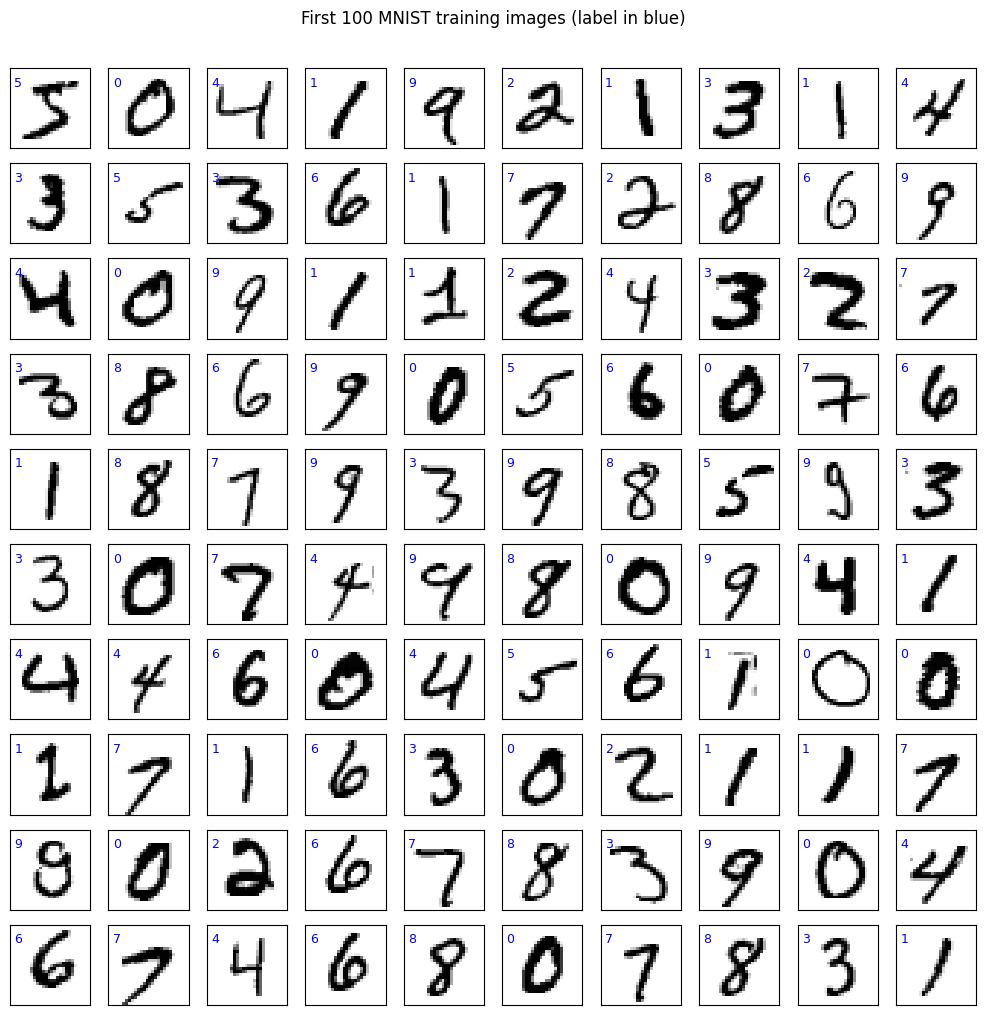

In [26]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_raw[i], cmap='binary', interpolation='nearest')
    ax.text(1, 6, str(y_train_raw[i]), color='blue', fontsize=9)
    ax.set(xticks=[], yticks=[])
plt.suptitle("First 100 MNIST training images (label in blue)", y=1.01)
plt.tight_layout()
plt.show()

## 1.6  Preprocessing

For a **fully-connected (Dense)** network we need to flatten 28×28 images into vectors of length 784.

| Step | Why |
|------|-----|
| `reshape(N, 784)` | Dense layers expect 1-D input |
| `astype(float32)` | GPU arithmetic works with floats |
| `/ 255` | Normalise pixels to [0, 1]; helps gradient flow |
| `to_categorical` | Convert label `7` → one-hot vector `[0,0,0,0,0,0,0,1,0,0]` |

In [27]:
# Flatten: (N, 28, 28) → (N, 784)
x_train = x_train_raw.reshape(-1, 784).astype('float32') / 255.0
x_test  = x_test_raw .reshape(-1, 784).astype('float32') / 255.0

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test  = tf.keras.utils.to_categorical(y_test_raw,  NUM_CLASSES)

print("x_train:", x_train.shape, "  range:", x_train.min(), "–", x_train.max())
print("y_train:", y_train.shape, "  example:", y_train[0])

x_train: (60000, 784)   range: 0.0 – 1.0
y_train: (60000, 10)   example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


> **Check ✏️**
> - What is the shape of `y_train`? Why does it have 10 columns?
> - What value would `y_train[0]` have if the first digit is `5`?

## 1.7  Build the DNN




###<span style="color:#000000">Models in Keras are defined as a sequence of layers\.</span>

<span style="color:#000000">We create a Sequential model and add layers one at a time until we are happy with our network architecture\.</span>

<span style="color:#000000">The first thing to get right is to ensure the input layer has the right number of input features\. This can be specified when creating the first layer with 512 nodes and with the input\_dim argument and setting it to 784 for the 784 input variables\.</span>

<code>
<span style="color:#000000">model = Sequential()</span>

<span style="color:#000000">model\.add\(Dense\(</span>  <span style="color:#09885A">512</span>  <span style="color:#000000">\, activation=</span>  <span style="color:#A31515">'relu'</span>  <span style="color:#000000">\, input\_shape=\(</span>  <span style="color:#09885A">784</span>  <span style="color:#000000">\,\)\)\)</span>
</code>

<span style="color:#000000">The activation function is relu </span>
<span style="color:#000000">\(Rectified Linear\):</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_648.png' width=450px>

---


### Adding next layers. How do we know the number of layers and their types?

<span style="color:#000000">This is a very hard question\. There are heuristics that we can use and often the best network structure is found through a process of trial and error experimentation\. Generally\, you need a network large enough to capture the structure of the problem\.</span>

<span style="color:#000000">In this example\, we will use a fully\-connected network structure with three hidden layers\.</span>

<span style="color:#000000">Fully connected layers are defined using the Dense class\. We can specify the number of neurons or nodes in the layer as the first argument\, and specify the activation function using the activation argument\.</span>

<span style="color:#000000">We will use the rectified linear unit activation function referred to as ReLU on the first three layers:</span>

<code>
model = Sequential()<br>
model.add(Dense(512, activation='relu', input_shape=(784,)))<br>
model.add(Dense(512, activation='relu'))<br>
model.add(Dense(512, activation='relu'))<br>
</code>


Adding output layer with num\_classes=10 nodes and softmax  activation function\. We use a softmax on the output layer to ensure our network outputs are between 0 and 1 and easy to map to either probabilities of all classes or snap to a hard classification of a class with maximum probability.



### Softmax activation function

Softmax function\, a wonderful activation function that turns numbers aka logits into probabilities that sum to one\. Softmax function outputs a vector that represents the probability distributions of a list of potential outcomes\. It’s also a core element used in deep learning classification tasks\.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_649.png' width=450px>
<br>


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_650.png' width=450px>

### Dropout

Between the layers we add a Dropout layer to avoid overtraining.

Dropout consists in randomly setting a fraction rate of input units to 0 at each update during training time\, which helps prevent overfitting\.



---


 “I went to my bank. The tellers kept changing and I asked one of them why. He said he didn’t know but they got moved around a lot. I figured it must be because it would require cooperation between employees to successfully defraud the bank. This made me realize that randomly removing a different subset of neurons on each example would prevent conspiracies and thus reduce overfitting.”

Geoffrey Hinton

<img src="https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2025/refs/heads/main/images/Zrzut%20ekranu%202025-03-25%20112940.png" width=450px>
<img src="https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2025/refs/heads/main/images/Zrzut%20ekranu%202025-03-25%20113154.png" width=450px>

*Original article:
[http://www\.jmlr\.org/papers/volume15/srivastava14a/srivastava14a\.pdf](http://www.jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)*




At the end we call:

<code>
<span style="color:#000000">model.summary()</span>  <span style="color:#000000"> </span>
</code>

  <span style="color:#000000"> print the network structure</span>


In [28]:
dnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax'),
], name='DNN_baseline')

dnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "DNN_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 383,242 (1.46 MB)

 Trainable params: 383,242 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

> **Check ✏️**
> - How many trainable parameters are there in total?
> - Which layer has the most parameters? Why?

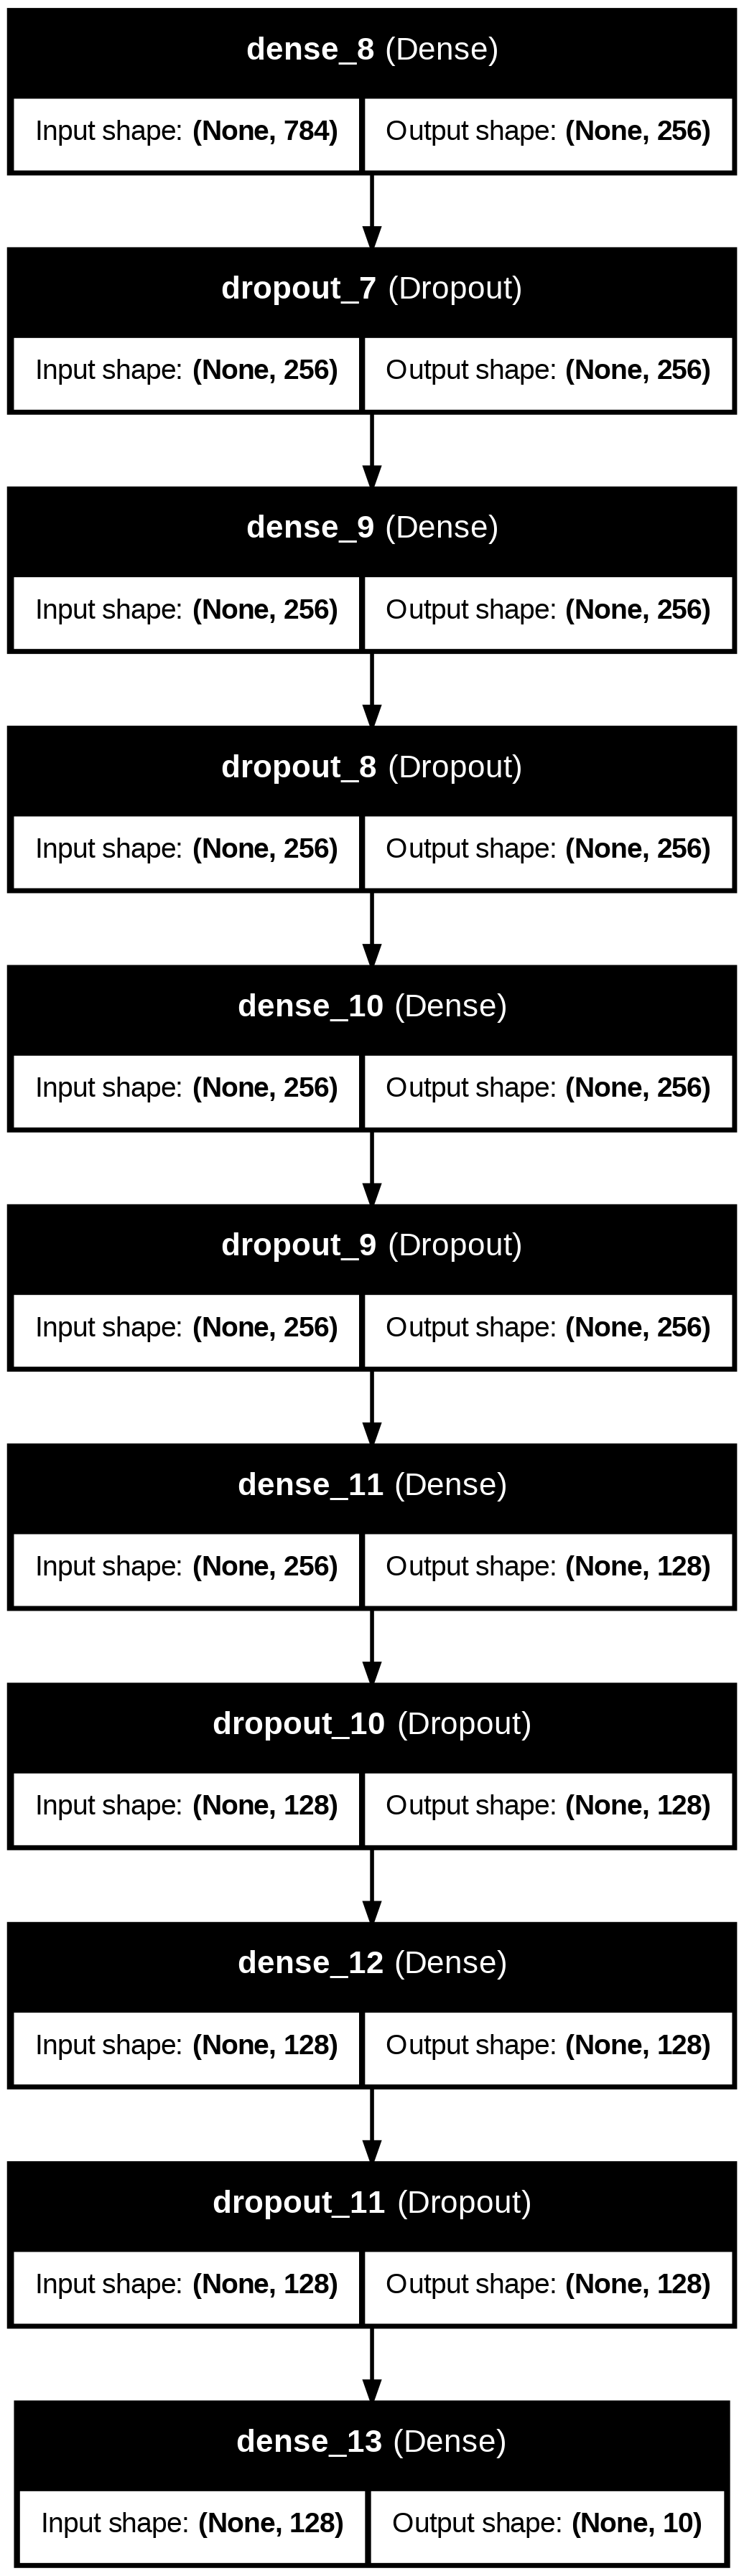

In [29]:
plot_model(dnn_model, to_file='dnn_plot.png', show_shapes=True, show_layer_names=True)
Image('dnn_plot.png')

## 1.8  Compile and train

When compiling\, we must specify some additional properties. Training a network means finding the best set of weights to map inputs to outputs in our dataset\.

* We must specify the loss function to use to evaluate a set of weights\, the optimizer is used to search through different weights for the network and any optional metrics we would like to collect and report during training\.

* This loss is for a categorical classification problems and is defined in Keras as “ _categorical\_crossentropy_ “\. You can learn more about choosing loss functions based on your problem here:

> [https://machinelearningmastery\.com/how\-to\-choose\-loss\-functions\-when\-training\-deep\-learning\-neural\-networks/](https://machinelearningmastery.com/how-to-choose-loss-functions-when-training-deep-learning-neural-networks/)

We can define the optimizer as the efficient stochastic gradient descent algorithm “ _RMSprop_ “\. We could also use “Adam”\, which is a popular version of gradient descent because it automatically tunes itself and gives good results in a wide range of problems\.


**Loss function:** `categorical_crossentropy` — standard for multi-class classification with one-hot labels.

**Optimizer:** Adam — an adaptive gradient descent that tunes its own learning rate.

**EarlyStopping:** stops training when validation loss stops improving, restores the best weights automatically.


We  train (fit) our model on our loaded data by calling the fit\(\) function on the model\.
Training occurs over epochs and each epoch is split into batches\.

* **Epoch:** One pass through all of the rows in the training dataset\.

* **Batch:**  One or more samples considered by the model within an epoch before weights are updated\.

One epoch is comprised of one or more batches\, based on the chosen batch size\.
For our digit recognition\, we will run for a small number of epochs \(20\) and use a  batch size of 128\.

These configurations can be chosen experimentally by trial and error\. We want to train the model enough so that it learns a good \(or good enough\) mapping of rows of input data to the output classification\. The model will always have some error\, but the amount of error will level out after some point for a given model configuration\. This is called model convergence\.

### A hint

Use GPU - it makes DNN much faster!

In [30]:
dnn_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

dnn_history = dnn_model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8739 - loss: 0.4056 - val_accuracy: 0.9579 - val_loss: 0.1469
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9546 - loss: 0.1624 - val_accuracy: 0.9719 - val_loss: 0.1029
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9664 - loss: 0.1223 - val_accuracy: 0.9734 - val_loss: 0.0920
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9706 - loss: 0.1019 - val_accuracy: 0.9761 - val_loss: 0.0873
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9752 - loss: 0.0857 - val_accuracy: 0.9785 - val_loss: 0.0821
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9780 - loss: 0.0774 - val_accuracy: 0.9797 - val_loss: 0.0780
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9805 - loss: 0.0679 - val_accuracy: 0.9793 - val_loss: 0.0828
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9817 - loss: 0.0624 - val_accuracy: 0

## 1.9  Evaluate: training curves

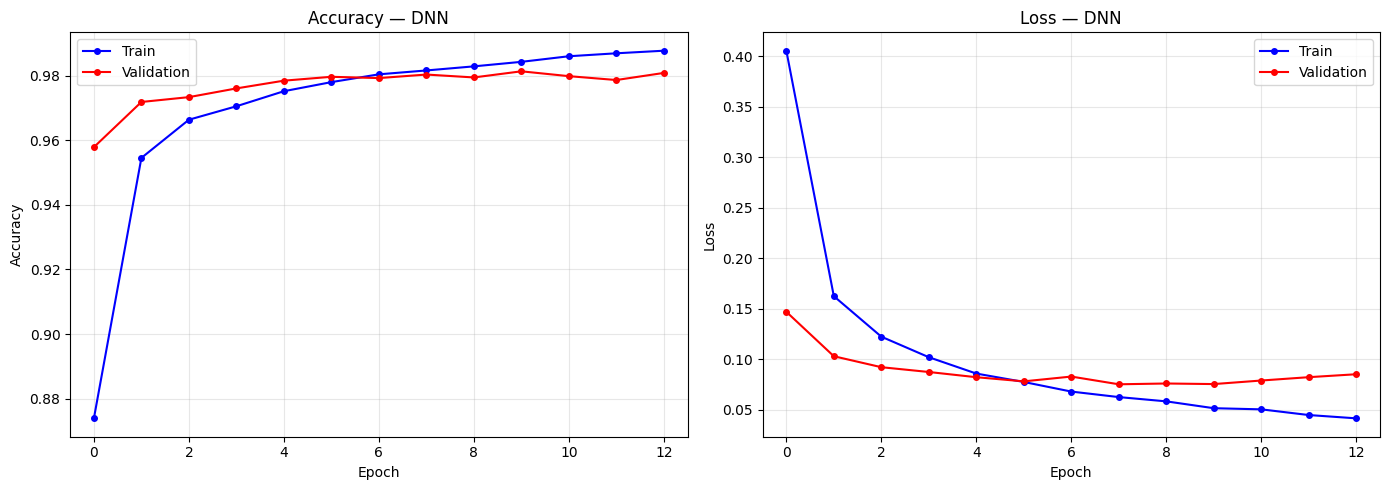

In [31]:
def plot_history(hist, title_suffix=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    n = len(hist.history['loss'])

    ax1.plot(hist.history['accuracy'],     'b-o', ms=4, label='Train')
    ax1.plot(hist.history['val_accuracy'], 'r-o', ms=4, label='Validation')
    ax1.set(xlabel='Epoch', ylabel='Accuracy', title=f'Accuracy {title_suffix}',
            xlim=[-0.5, n-0.5])
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(hist.history['loss'],     'b-o', ms=4, label='Train')
    ax2.plot(hist.history['val_loss'], 'r-o', ms=4, label='Validation')
    ax2.set(xlabel='Epoch', ylabel='Loss', title=f'Loss {title_suffix}',
            xlim=[-0.5, n-0.5])
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(dnn_history, '— DNN')

> **Check ✏️ — Is the model overfitting?**
> Look at the gap between train and validation curves:
> - If validation accuracy *levels off* while train accuracy keeps rising → **overfitting**
> - If both curves are still improving → the model could benefit from more epochs

We have trained our neural network on the entire dataset and we can evaluate the performance of the network on another “test” dataset using the evaluate\(\) function\.
This will generate a prediction for each input and output pair and collect scores\, including the average loss and any metrics you have configured\, such as accuracy\.

The evaluate\(\) function returns a list with two values\. The first is the loss of the model on the given dataset and the second is the accuracy of the model.

In [32]:
score = dnn_model.evaluate(x_test, y_test, verbose=0)
print(f"DNN — Test loss: {score[0]:.4f}  |  Test accuracy: {score[1]*100:.2f}%")

DNN — Test loss: 0.0751  |  Test accuracy: 98.04%


### Score:

We got over 98.1% - 98.6% of good answers! Let's compare it with our previous MNIST classifiers:
* PCA + Naive Bayes - 94.8%
* Shallow neural network 97.7%


## 1.10  Confusion matrix

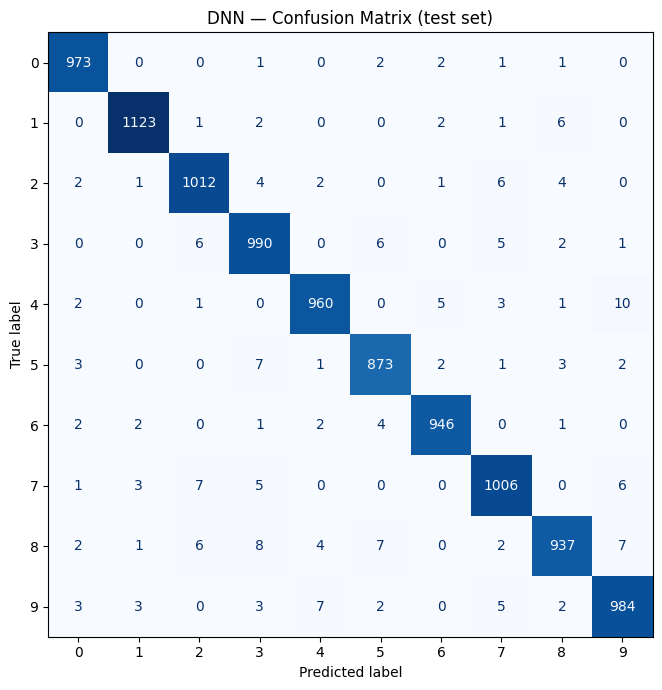

In [33]:
y_pred_dnn = np.argmax(dnn_model.predict(x_test, verbose=0), axis=1)
cm_dnn = confusion_matrix(y_test_raw, y_pred_dnn)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(cm_dnn)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.set_title('DNN — Confusion Matrix (test set)')
plt.tight_layout()
plt.show()

> **Check ✏️**
> - Which digit pair is most often confused? Does that make visual sense?
> - The diagonal shows correct predictions. Off-diagonal cells are errors.

## 1.11  Visualise correct (green) and wrong (red) predictions

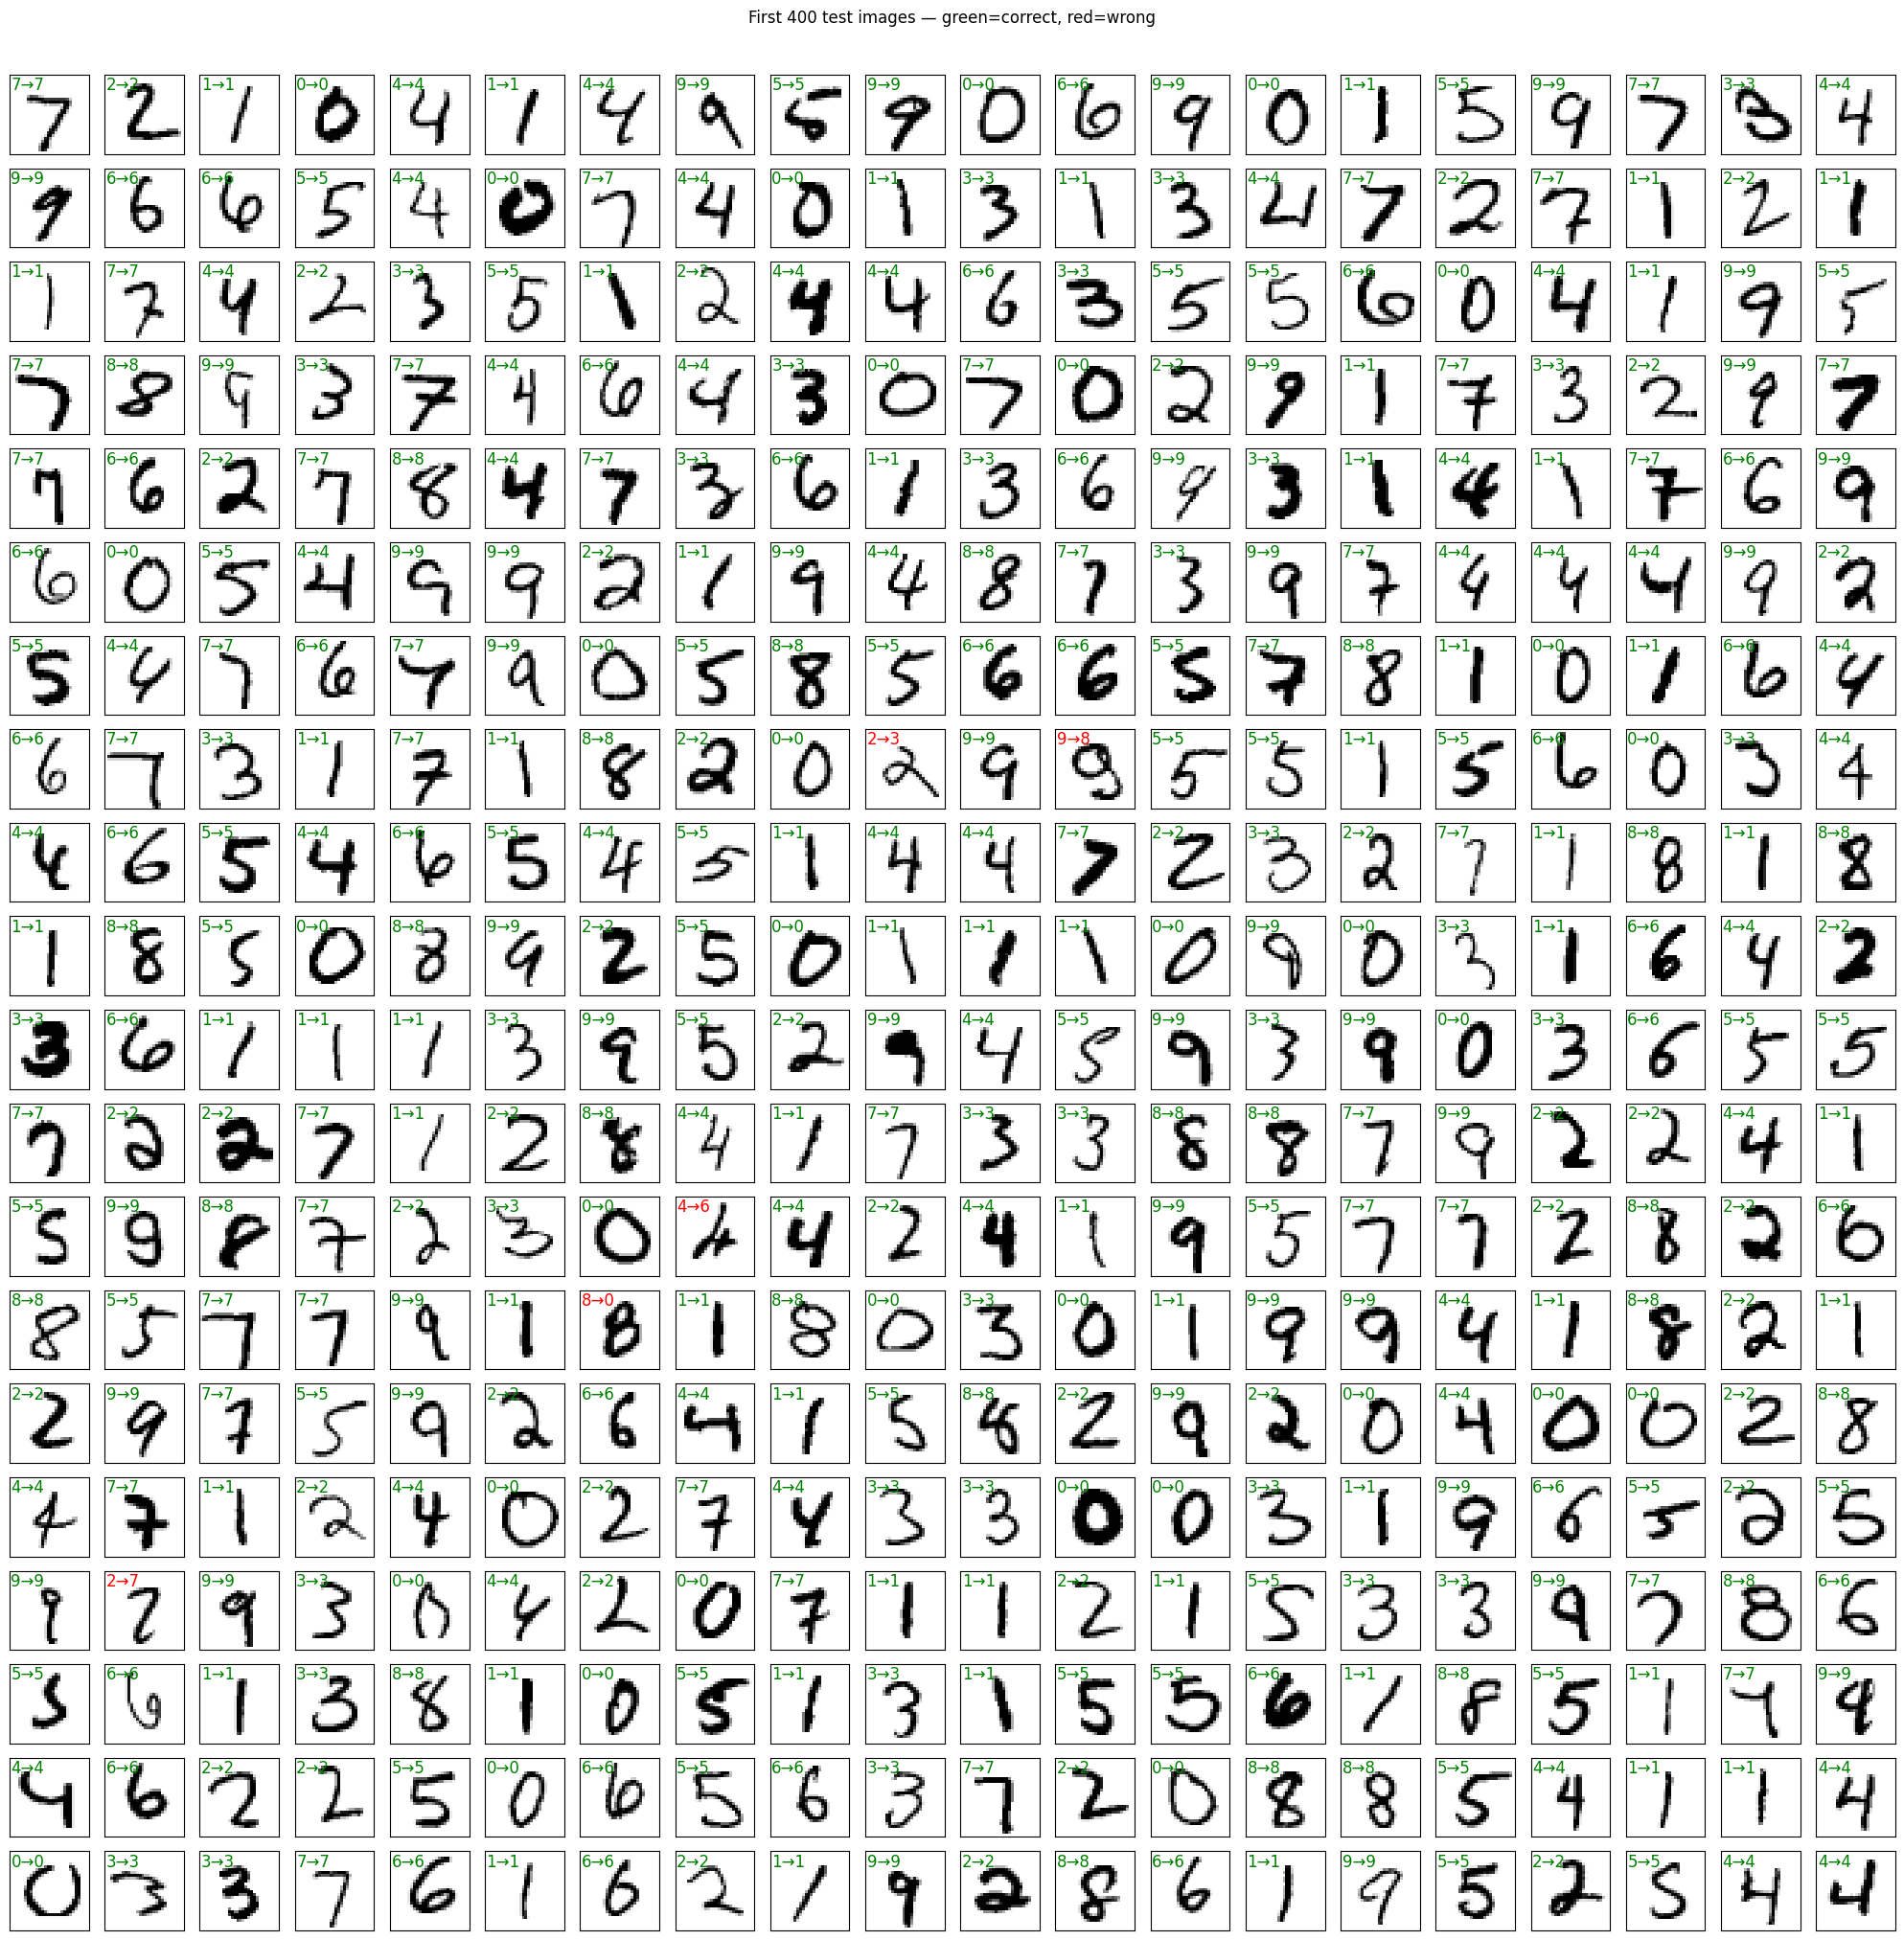

In [34]:
predicted_labels = np.argmax(dnn_model.predict(x_test, verbose=0), axis=1)

fig, axes = plt.subplots(20, 20, figsize=(20, 20))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28, 28), cmap='binary', interpolation='nearest')
    true_l, pred_l = y_test_raw[i], predicted_labels[i]
    color = 'green' if true_l == pred_l else 'red'
    ax.text(0, 5, f"{true_l}→{pred_l}", color=color, fontsize=12)
    ax.set(xticks=[], yticks=[])
plt.suptitle("First 400 test images — green=correct, red=wrong", y=1.01)
plt.tight_layout()
plt.show()

## ✏️ Exercises — DNN

Work through these in order. Record your test accuracy in the table below.

### Exercise 1: Tune Dropout
Change `Dropout(0.2)` to each value below, retrain, note accuracy:

| Dropout | Expected effect | Your accuracy |
|---------|----------------|---------------|
| 0.0 | No regularisation | 97.96% |
| 0.2 | Baseline | 98.23% |
| 0.5 | Strong regularisation | 98.02% |

**Question:** At which dropout value is the train–validation gap smallest?
**Answer:** At 0.5

### Exercise 2: Change the optimizer
Replace `Adam()` with `Adam(learning_rate=0.0001)`/`Adam(learning_rate=0.1)`/`RMSprop(learning_rate=0.0001)`. Does it converge faster or slower? Why?

From the principle of operation of the backpropagation algorithm, a lower learning rate means slower learning, but a value that is too high can cause the learning process not to converge.

### Exercise 3: Change network depth
Add a 4th (and 5th) hidden layer `Dense(128, activation='relu')` before the output.  
Does it improve accuracy? Check the parameter count with `model.summary()`.

**Answer:** No better accuracy in this case.

## 1.12 Summary

* we have learned about neural networks, and ...
* <span style="color:#000000"> __...we have built our very first Deep Neural Network\!\!\!__ </span>



<center>

---
---

# 🟢 Part 2: Convolutional Neural Networks
### Why flattening images loses information

---
---
</center>

## 2.1  The problem with fully-connected networks on images

When we flattened 28×28 into 784 values, we destroyed **spatial structure**: pixels that were neighbours are no longer neighbours in the vector.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_714.png' width=420>

**Consequence:** the DNN must learn the same feature (e.g. "horizontal edge") independently for every possible position in the image. This is wasteful and makes it fragile to small shifts.

### A small shift

See what happens if we shift an image by three pixels.

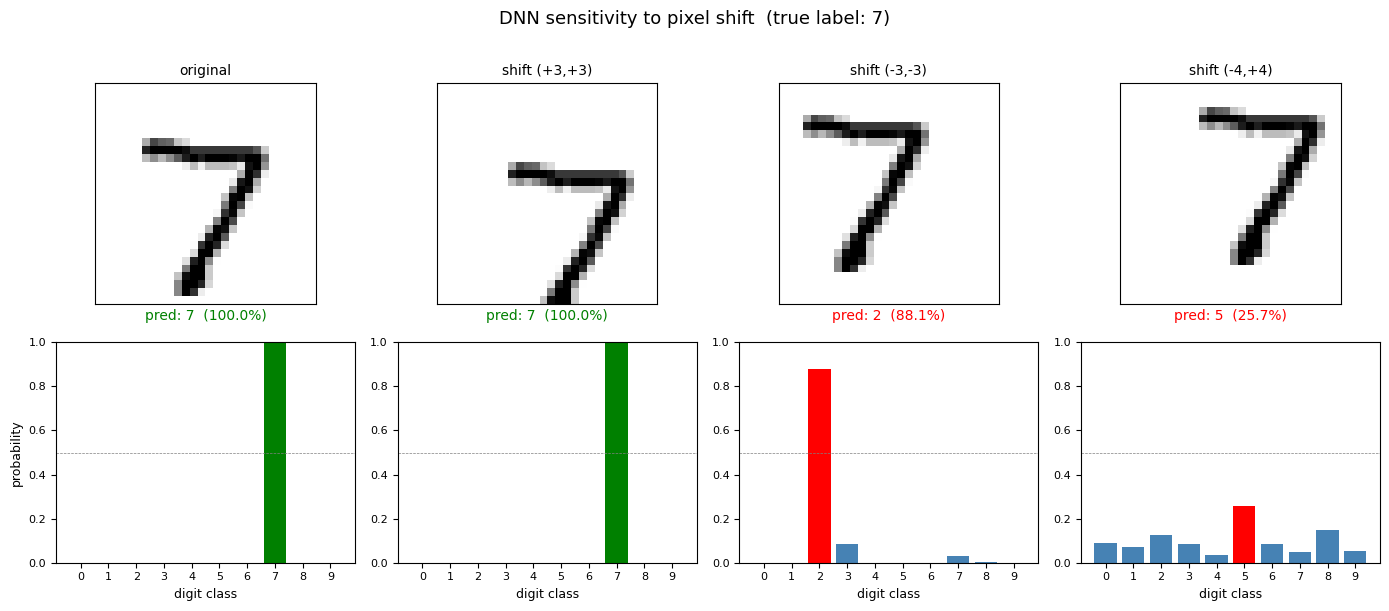

In [35]:
# The DNN treats these two images identically if the digit is shifted by 1 pixel
# Let's demonstrate the problem: shift an image and check the DNN's confidence
from scipy.ndimage import shift

# ── pick one test image ──────────────────────────────────────────────────────
idx = 0
original_2d = x_test[idx].reshape(28, 28)   # already float32 in [0,1]

# ── create shifted versions ──────────────────────────────────────────────────
# shift([row_offset, col_offset]) — positive = down/right
shifts = [(0, 0), (3, 3), (-3, -3), (-4, 4)]
labels = ["original", "shift (+3,+3)", "shift (-3,-3)", "shift (-4,+4)"]

fig, axes = plt.subplots(2, len(shifts), figsize=(14, 6))
fig.suptitle(f"DNN sensitivity to pixel shift  (true label: {y_test_raw[idx]})",
             fontsize=13, y=1.01)

for col, (dy, dx), lbl in zip(range(len(shifts)), shifts, labels):
    img_shifted = shift(original_2d, [dy, dx])          # values stay in [0,1]
    flat = img_shifted.reshape(1, 784)

    probs   = dnn_model.predict(flat, verbose=0)[0]
    pred    = np.argmax(probs)
    conf    = probs[pred] * 100

    # ── top row: image ───────────────────────────────────────────────────────
    ax_img = axes[0, col]
    ax_img.imshow(img_shifted, cmap="binary", interpolation="nearest",
                  vmin=0, vmax=1)
    correct = (pred == y_test_raw[idx])
    color   = "green" if correct else "red"
    ax_img.set_title(lbl, fontsize=10)
    ax_img.set_xlabel(f"pred: {pred}  ({conf:.1f}%)", color=color, fontsize=10)
    ax_img.set(xticks=[], yticks=[])

    # ── bottom row: probability bar chart ───────────────────────────────────
    ax_bar = axes[1, col]
    bar_colors = ["steelblue"] * 10
    bar_colors[pred] = color
    ax_bar.bar(range(10), probs, color=bar_colors)
    ax_bar.set_xticks(range(10))
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xlabel("digit class", fontsize=9)
    if col == 0:
        ax_bar.set_ylabel("probability", fontsize=9)
    ax_bar.tick_params(labelsize=8)
    ax_bar.axhline(0.5, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

## 2.2  The CNN solution

A **Convolutional layer** slides a small filter (e.g. 3×3) over the entire image, applying the *same weights* at every position. This gives two key benefits:

| Property | Meaning |
|----------|---------|
| **Weight sharing** | The filter to detect "horizontal edge" is learned once, applied everywhere |
| **Translation invariance** | The network recognises a feature regardless of where in the image it appears |



## 2.3  How features build up layer by layer




### Each layer is finding more and more complicated features

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/img27.png' width=650px>



###An important remark:

Each "feature detector" detects a feature only in a given place on picture. This means that to detect for example "a horizontal line" in any region of an image we need many independant horizontal line detectors each looking at different point in image.


### Convolutional Neural Network Pattern recognition

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_715.png' width=450px>

<span style="color:#000000">Many connections… How to simplify the deep neural network?</span>

### Convolutional NN

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_716.png' width=450px>

<span style="color:#000000">Just connect only local areas\, for example 10x10 pixels\. </span>

<span style="color:#000000">Huge reduction of the number of parameters\!</span>

<span style="color:#000000">The same features might be found in different places => so we could train many filters\, each recognizing another feature\, and move them over the picture\.</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_717.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_718.png' width=450px>



### Pooling

In pooling  (in most cases </span>  <span style="color:#000000"> __max pooling__ </span>  <span style="color:#000000">\) the group of outputs for a larger input area is replaced by a maximum \(or average\) for this given area:</span>

* <span style="color:#000000">Data reduction\,</span>
* <span style="color:#000000">Lower sensitivity for the position of a given feature\.</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_720.png' width=450px>



<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_719.png' width=450px>


### Convolutional network - a winner of ILSVRC-2012 challenge

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_722.png' width=450px>




<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_723.png' width=450px>

<span style="color:#000000">(\*) *SIFT \- scale\-invariant feature transform\, algorithm published in 1999 roku by David Lowe\.</span>*



<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_724.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_725.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_726.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_727.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_728.png' width=450px>



### Few properties of Deep Neural Networks

Have a look at: <br>
*http://www.deeplearningbook.org*

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_729.png' width=450px>

<br>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_730.png' width=450px>




### Nice blog entry about convolutional neural networks:

https://towardsdatascience.com/convolutional-neural-networks-explained-9cc5188c4939

<img src='https://miro.medium.com/max/1400/1*kkyW7BR5FZJq4_oBTx3OPQ.png' width=650px>

### Program demonstrating how the features in CNN are recognized

https://adamharley.com/nn_vis/


<img src='https://adamharley.com/images/vis10.gif' width=450px>


## 2.4  Prepare data for CNN

CNNs expect images with shape `(height, width, channels)` — **not** flattened vectors.

In [36]:
IMG_ROWS, IMG_COLS = 28, 28

# Keep the raw labels for visualisation
y_train_raw2 = y_train_raw.copy()
y_test_raw2  = y_test_raw.copy()

# Reshape to (N, 28, 28, 1) — 1 channel because MNIST is grayscale
x_train_cnn = x_train_raw.reshape(-1, IMG_ROWS, IMG_COLS, 1).astype('float32') / 255.0
x_test_cnn  = x_test_raw .reshape(-1, IMG_ROWS, IMG_COLS, 1).astype('float32') / 255.0

# One-hot labels (same as before)
y_train_cnn = tf.keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test_cnn  = tf.keras.utils.to_categorical(y_test_raw,  NUM_CLASSES)

print("x_train_cnn shape:", x_train_cnn.shape)   # (60000, 28, 28, 1)
print("y_train_cnn shape:", y_train_cnn.shape)   # (60000, 10)

x_train_cnn shape: (60000, 28, 28, 1)
y_train_cnn shape: (60000, 10)


## 2.5  Build the CNN

### Architecture at a glance

```
Input (28×28×1)
  └─ Conv2D(32, 3×3, relu)    → 26×26×32
  └─ Conv2D(64, 3×3, relu)    → 24×24×64
  └─ MaxPooling2D(2×2)        → 12×12×64
  └─ Dropout(0.25)
  └─ Conv2D(64, 3×3, relu)    → 10×10×64
  └─ Conv2D(64, 3×3, relu)    → 8×8×64
  └─ MaxPooling2D(2×2)        → 4×4×64
  └─ Dropout(0.25)
  └─ Flatten                  → 1024
  └─ Dense(128, relu)
  └─ Dropout(0.5)
  └─ Dense(10, softmax)       → probabilities
```

In [37]:
input_shape_cnn = (IMG_ROWS, IMG_COLS, 1)

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape_cnn),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.0),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.0),
    Dense(NUM_CLASSES, activation='softmax'),
], name='CNN_baseline')

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,810 (2.29 MB)

 Trainable params: 600,810 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

> **Check ✏️**
> - Compare the parameter count with the DNN. Which has more? Why?
> - After `Flatten()`, what is the size of the vector?

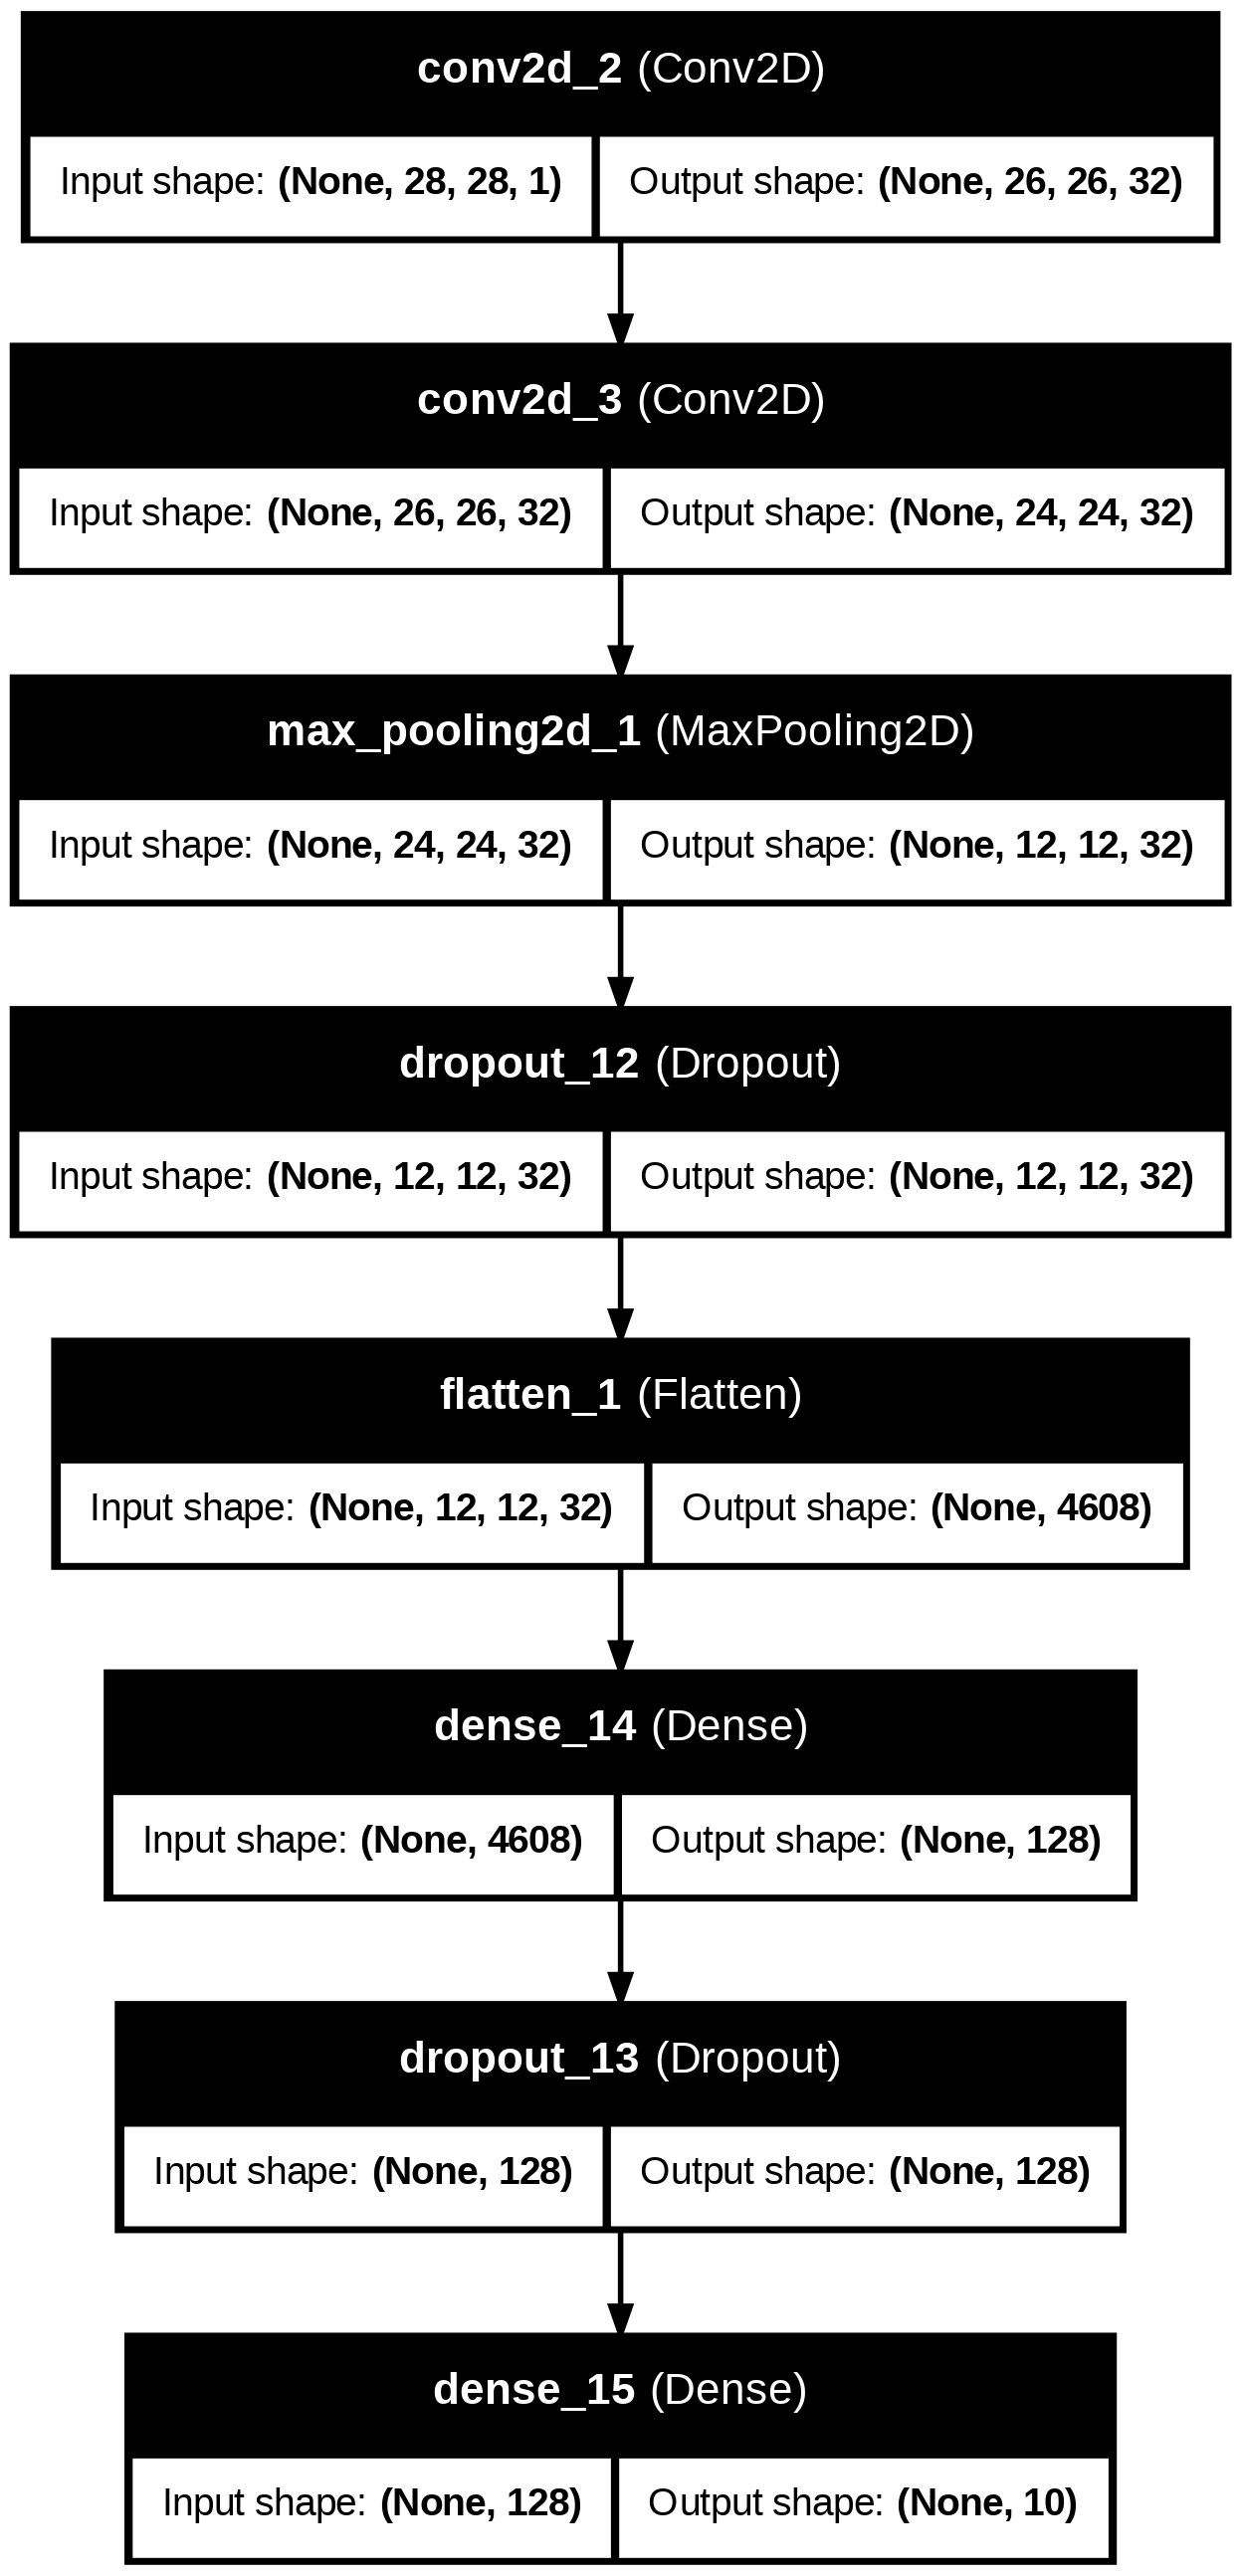

In [38]:
plot_model(cnn_model, to_file='cnn_plot.png', show_shapes=True, show_layer_names=True)
Image('cnn_plot.png')

## 2.6  Train the CNN

In [39]:
cnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

cnn_history = cnn_model.fit(
    x_train_cnn, y_train_cnn,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test_cnn, y_test_cnn),
    callbacks=[early_stop_cnn],
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9509 - loss: 0.1716 - val_accuracy: 0.9806 - val_loss: 0.0603
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9858 - loss: 0.0470 - val_accuracy: 0.9835 - val_loss: 0.0496
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9910 - loss: 0.0298 - val_accuracy: 0.9837 - val_loss: 0.0502
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9943 - loss: 0.0197 - val_accuracy: 0.9864 - val_loss: 0.0445
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9961 - loss: 0.0134 - val_accuracy: 0.9880 - val_loss: 0.0392
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9965 - loss: 0.0110 - val_accuracy: 0.9881 - val_loss: 0.0454
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9966 - loss: 0.0102 - val_accuracy: 0.9883 - val_loss: 0.0449
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9978 - loss: 0.0072 - val_accuracy: 0.

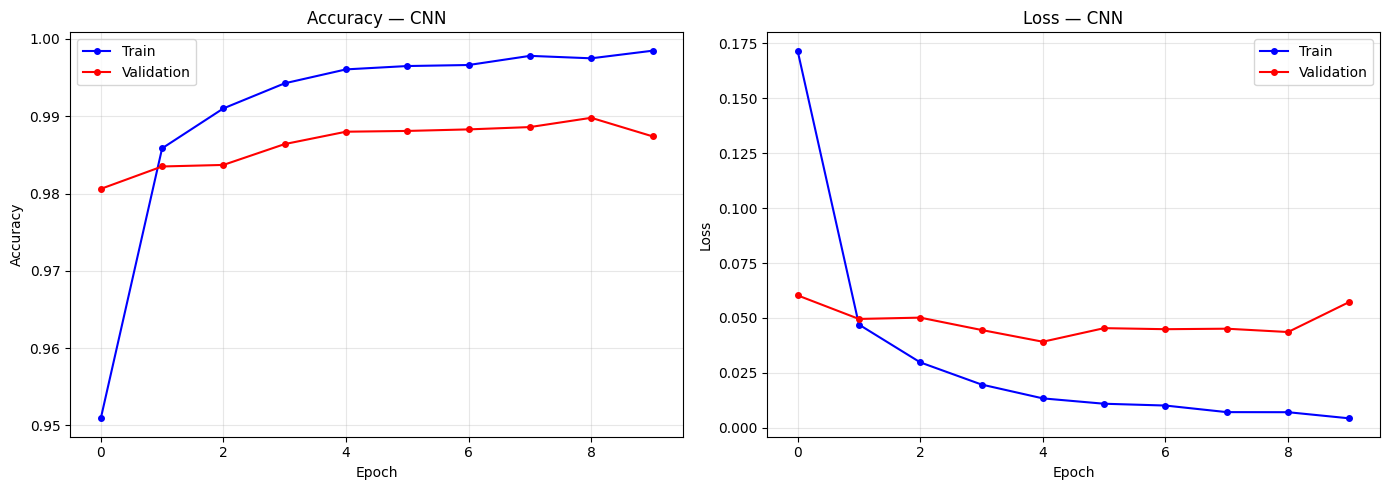

CNN — Test loss: 0.0392  |  Test accuracy: 98.80%


In [40]:
plot_history(cnn_history, '— CNN')

score_cnn = cnn_model.evaluate(x_test_cnn, y_test_cnn, verbose=0)
print(f"CNN — Test loss: {score_cnn[0]:.4f}  |  Test accuracy: {score_cnn[1]*100:.2f}%")

## 2.7  DNN vs CNN — side-by-side comparison

In [41]:
score_dnn = dnn_model.evaluate(x_test, y_test, verbose=0)
score_cnn = cnn_model.evaluate(x_test_cnn, y_test_cnn, verbose=0)

print("╔══════════════════════════════════════════════╗")
print("║          Model Comparison — MNIST            ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  DNN (fully-connected)  accuracy: {score_dnn[1]*100:.2f}%    ║")
print(f"║  CNN (convolutional)    accuracy: {score_cnn[1]*100:.2f}%    ║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║          Model Comparison — MNIST            ║
╠══════════════════════════════════════════════╣
║  DNN (fully-connected)  accuracy: 98.04%    ║
║  CNN (convolutional)    accuracy: 98.80%    ║
╚══════════════════════════════════════════════╝


> **Question ✏️:** Why does the CNN outperform the DNN, even though it may have *fewer* parameters?
> Think about: weight sharing, translation invariance, preservation of spatial structure.

## 2.8  CNN Confusion matrix

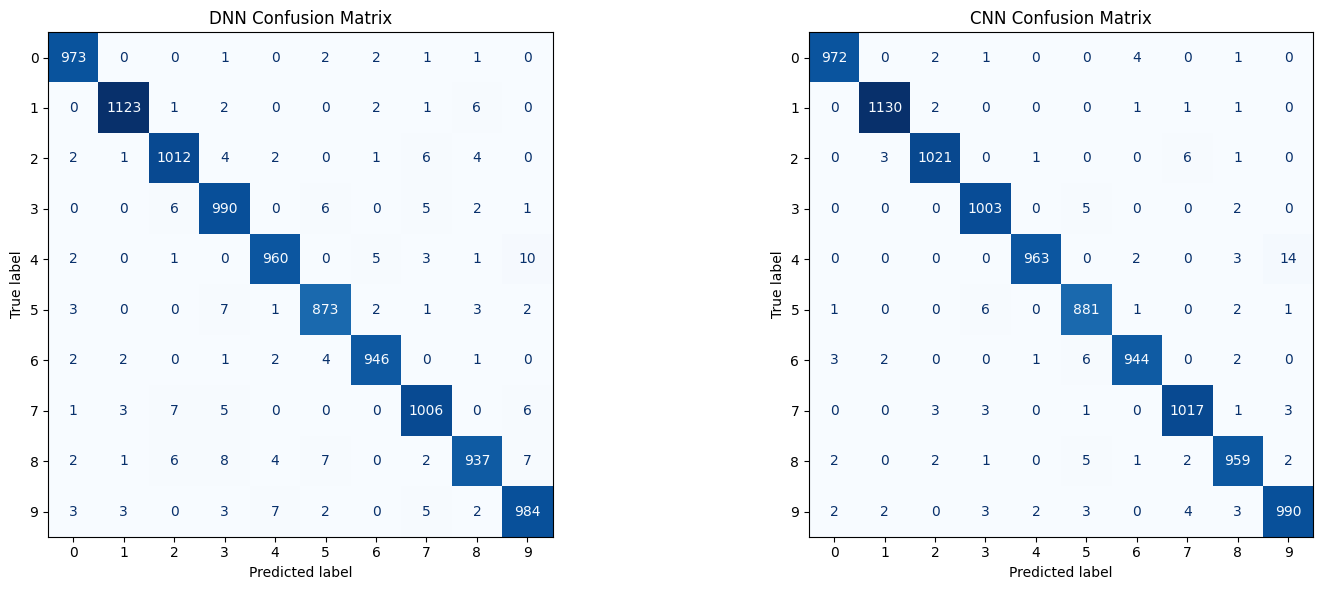

In [42]:
y_pred_cnn = np.argmax(cnn_model.predict(x_test_cnn, verbose=0), axis=1)
cm_cnn = confusion_matrix(y_test_raw, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cm, title in zip(axes,
                          [cm_dnn, cm_cnn],
                          ['DNN', 'CNN']):
    ConfusionMatrixDisplay(cm).plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(f'{title} Confusion Matrix')
plt.tight_layout()
plt.show()

## 2.9 A small shift test again

See what happens if we shift an image by three pixels.

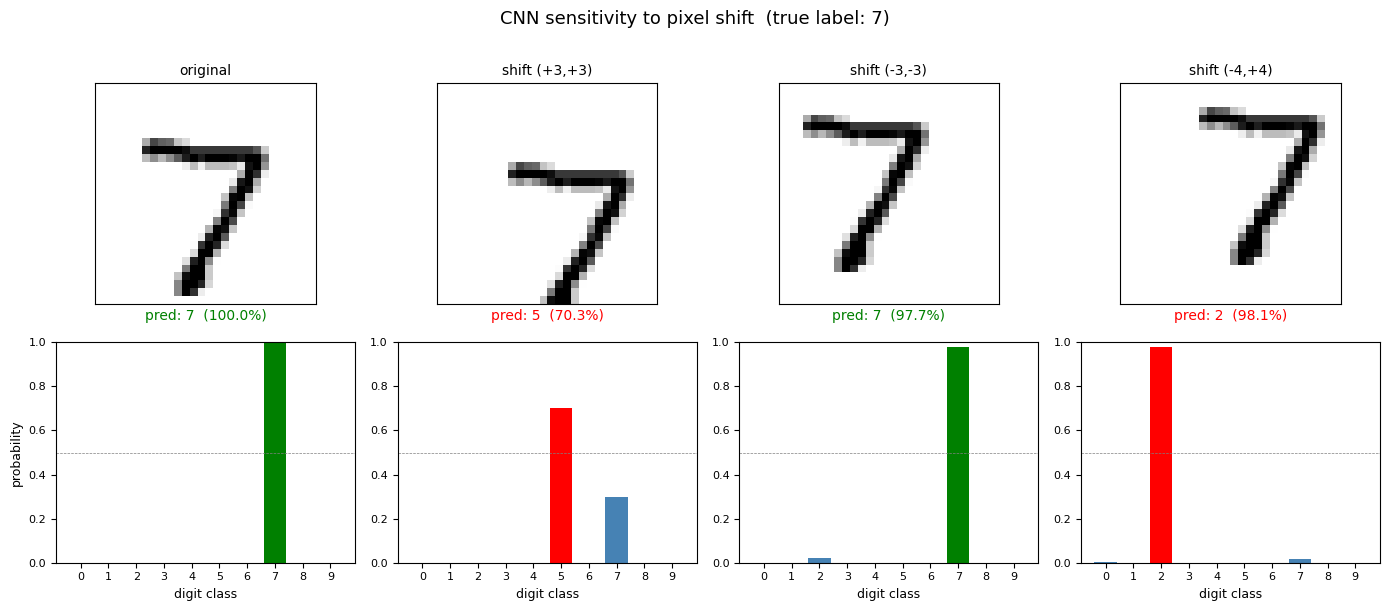

In [43]:
# The DNN/CNN treats these two images identically if the digit is shifted by 1 pixel
# Let's demonstrate the problem: shift an image and check the DNN's confidence
from scipy.ndimage import shift

# ── pick one test image ──────────────────────────────────────────────────────
idx = 0
original_2d = x_test_raw[idx].astype('float32') / 255.0   # shape (28, 28)

# ── create shifted versions ──────────────────────────────────────────────────
shifts = [(0, 0), (3, 3), (-3, -3), (-4, 4)]
labels = ["original", "shift (+3,+3)", "shift (-3,-3)", "shift (-4,+4)"]

fig, axes = plt.subplots(2, len(shifts), figsize=(14, 6))
fig.suptitle(f"CNN sensitivity to pixel shift  (true label: {y_test_raw2[idx]})",
             fontsize=13, y=1.01)

for col, (dy, dx), lbl in zip(range(len(shifts)), shifts, labels):
    img_shifted = shift(original_2d, [dy, dx])

    # CNN expects shape (1, 28, 28, 1)
    flat = img_shifted.reshape(1, 28, 28, 1)

    probs = cnn_model.predict(flat, verbose=0)[0]
    pred  = np.argmax(probs)
    conf  = probs[pred] * 100

    # ── top row: image ───────────────────────────────────────────────────────
    ax_img = axes[0, col]
    ax_img.imshow(img_shifted, cmap="binary", interpolation="nearest",
                  vmin=0, vmax=1)
    correct = (pred == y_test_raw2[idx])
    color   = "green" if correct else "red"
    ax_img.set_title(lbl, fontsize=10)
    ax_img.set_xlabel(f"pred: {pred}  ({conf:.1f}%)", color=color, fontsize=10)
    ax_img.set(xticks=[], yticks=[])

    # ── bottom row: probability bar chart ───────────────────────────────────
    ax_bar = axes[1, col]
    bar_colors = ["steelblue"] * 10
    bar_colors[pred] = color
    ax_bar.bar(range(10), probs, color=bar_colors)
    ax_bar.set_xticks(range(10))
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xlabel("digit class", fontsize=9)
    if col == 0:
        ax_bar.set_ylabel("probability", fontsize=9)
    ax_bar.tick_params(labelsize=8)
    ax_bar.axhline(0.5, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

## 2.10  Visualise correct (green) and wrong (red) predictions

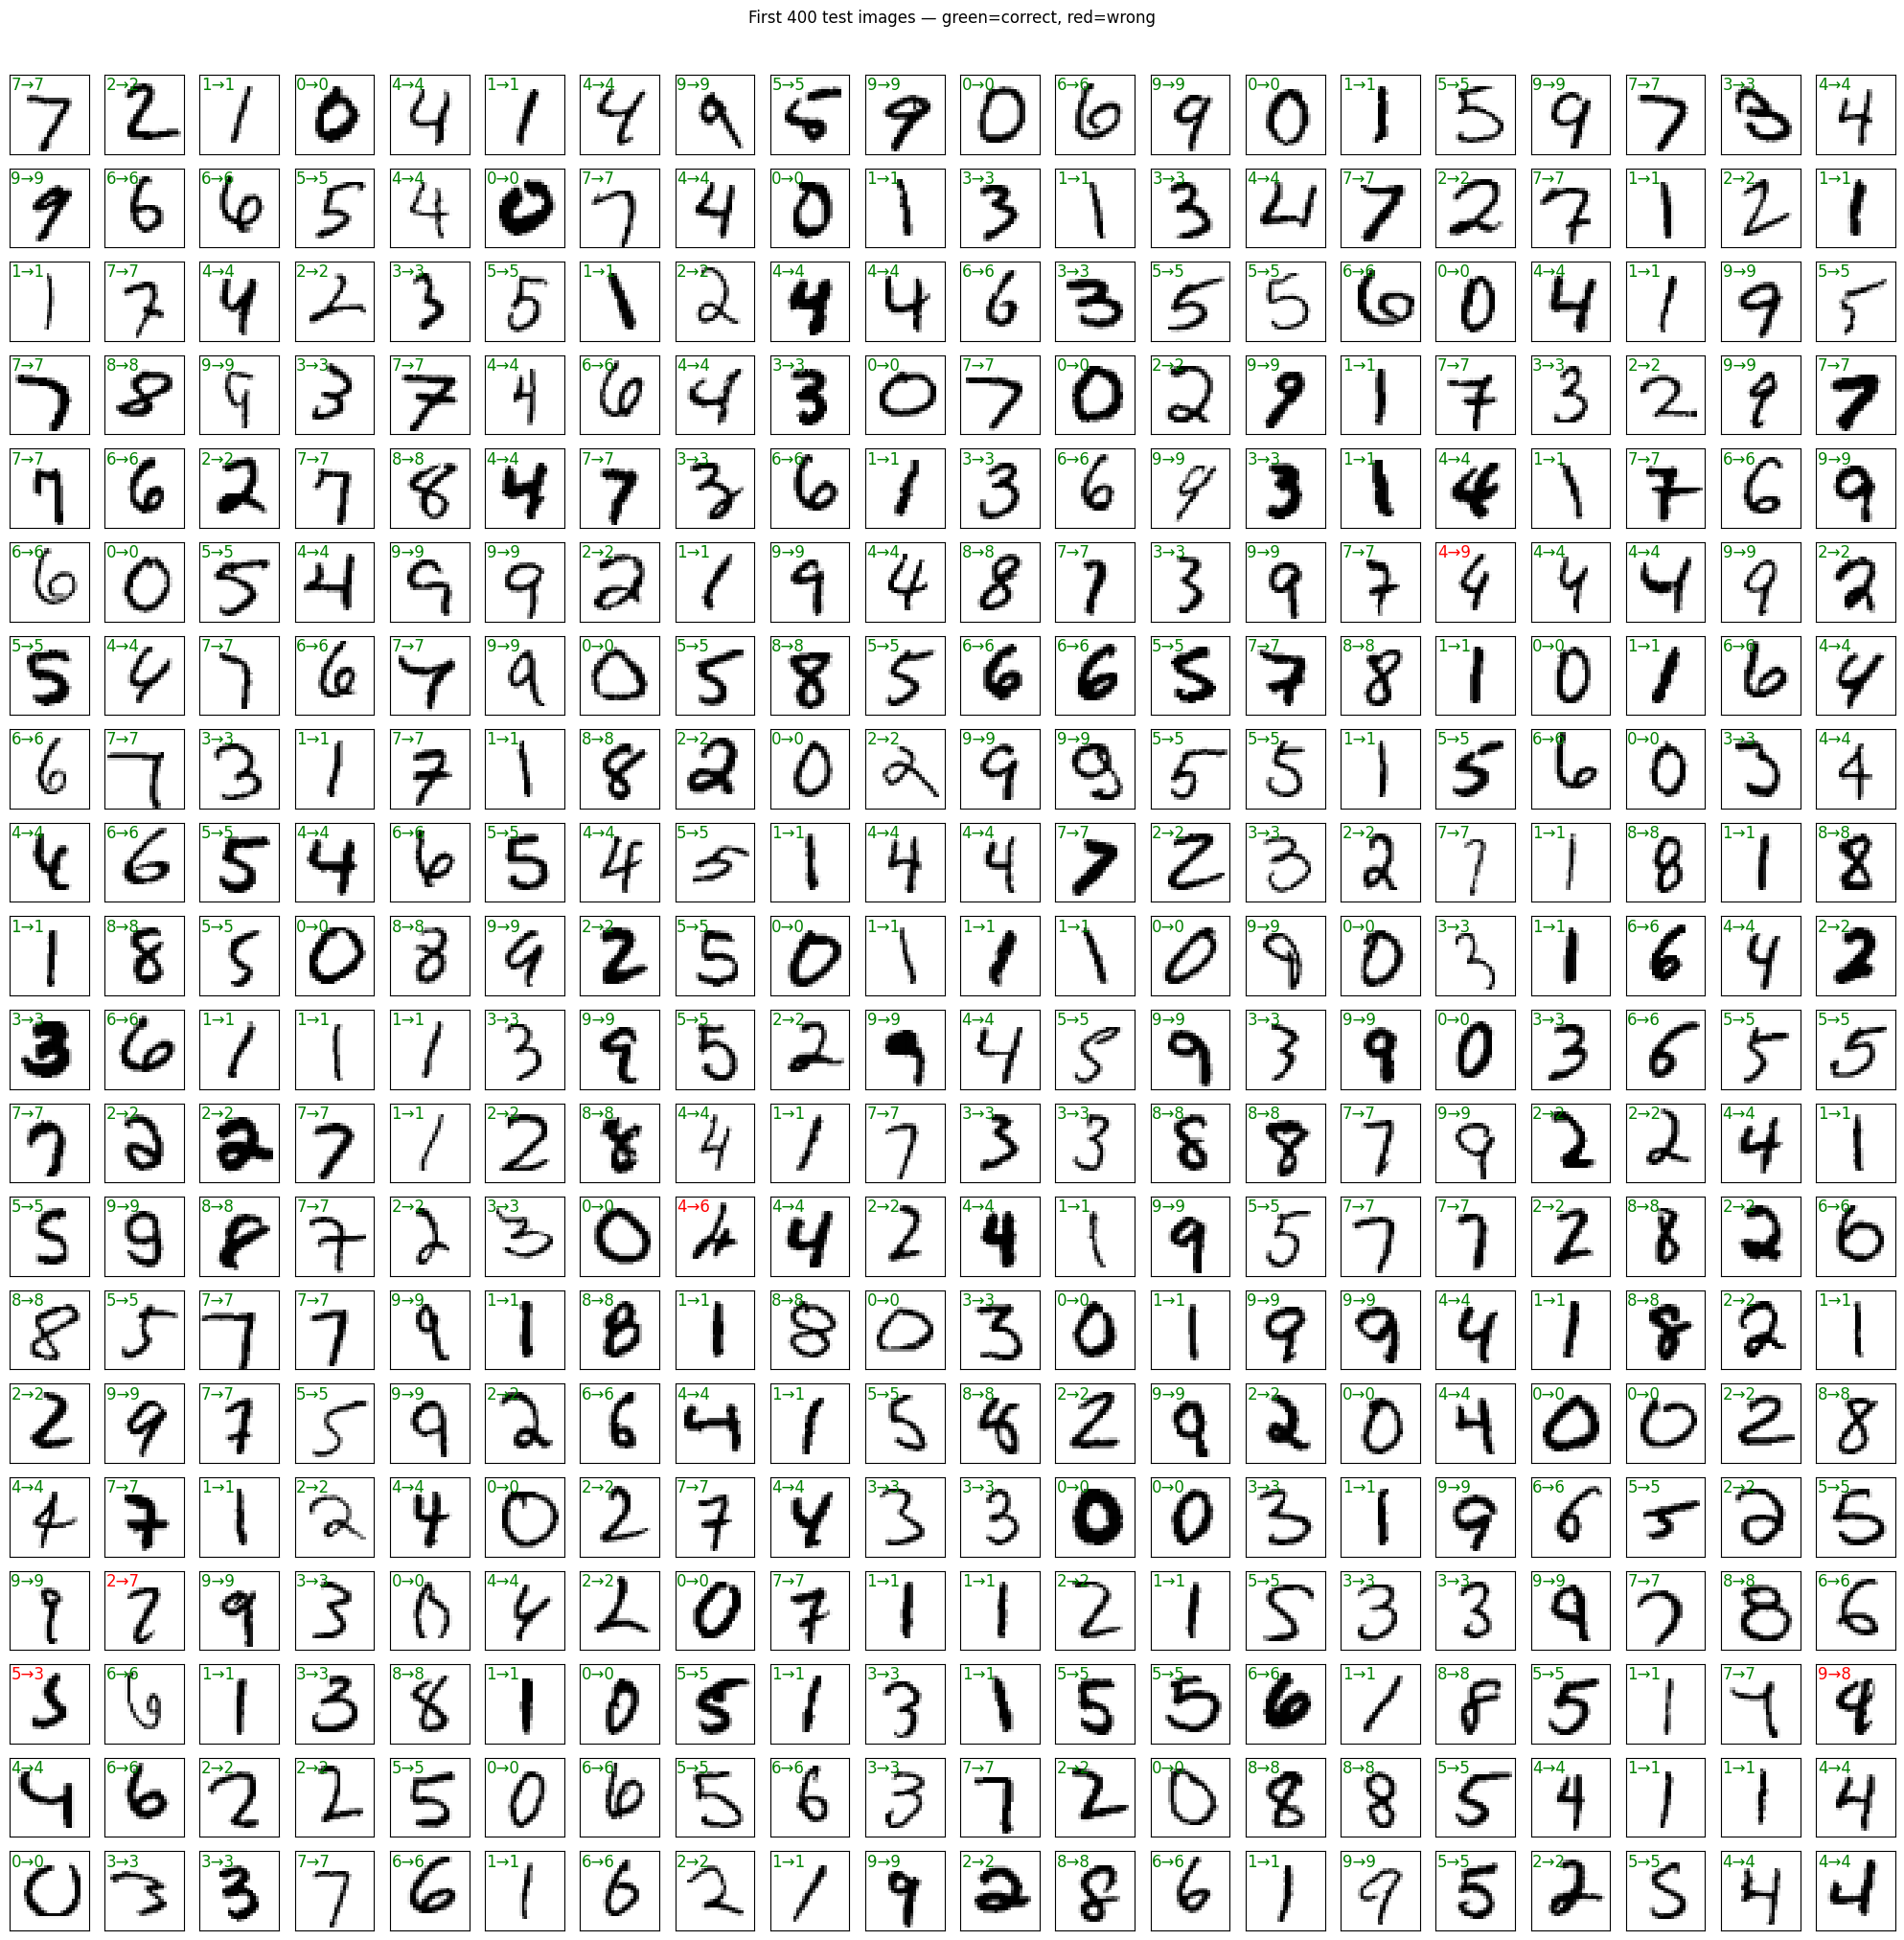

In [44]:
predicted_labels_cnn = np.argmax(cnn_model.predict(x_test_cnn, verbose=0), axis=1)

fig, axes = plt.subplots(20, 20, figsize=(20, 20))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test_cnn[i], cmap='binary', interpolation='nearest')
    true_l, pred_l = y_test_raw2[i], predicted_labels_cnn[i]
    color = 'green' if true_l == pred_l else 'red'
    ax.text(0, 5, f"{true_l}→{pred_l}", color=color, fontsize=12)
    ax.set(xticks=[], yticks=[])
plt.suptitle("First 400 test images — green=correct, red=wrong", y=1.01)
plt.tight_layout()
plt.show()

## 2.11 Is it possible to make this CNN even better?

* Train more networks in parallel and take an average as a classifier,
* Artificially increase the size of the training dataset - create more images by the *augmentation* procedure (next lecture).


### State of the art code for hand-written digits recognition

* 15 convolutional neural networks working in parallel
* image augmentation

Detailed description and code:

https://www.kaggle.com/cdeotte/25-million-images-0-99757-mnist

### Augmentation:

Artificially increase the number of training events by some modifications like: rotation, translation, shift etc.

```
# CREATE MORE IMAGES VIA DATA AUGMENTATION
datagen = ImageDataGenerator(
        rotation_range=10,  
        zoom_range = 0.10,  
        width_shift_range=0.1,
        height_shift_range=0.1)
```
<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/__results___8_0.png' width=650px>



## 2.12 Ensamble of 15 CNNs with advanced architecture:

The CNNs in this kernel follow [LeNet5's](https://hal.science/hal-03926082/document) design (pictured below) with the following improvements:

* Two stacked 3x3 filters replace the single 5x5 filters. These become nonlinear 5x5 convolutions
* A convolution with stride 2 replaces pooling layers. These become learnable pooling layers.
* ReLU activation replaces sigmoid.
* Batch normalization is added
* Dropout is added
* More feature maps (channels) are added
* **An ensemble of 15 CNNs with bagging is used**


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/LeNet5.png' width=650px>


#**Performance:**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/histBoth5.png' width=650px>


## 2.13 A Deep Neural Network Applet

Nice applet showing the performance of deep NN:

http://cs.stanford.edu/people/karpathy/convnetjs/

**Have fun playing!**

## ✏️ Exercises — CNN

### Exercise 1: Remove MaxPooling
Comment out both `MaxPooling2D` layers. Retrain.  
- What happens to the parameter count?  **Answer**: 225k -> 3 371k
- What happens to accuracy and training time? **Answer**: 99.47% -> 99.33% (and longer time)

### Exercise 2: Remove Dropout
Set all Dropout rates to 0.0. Look at the training curves carefully.  
- Do you see overfitting? At which epoch does it start? **Answer**: Yes, from 5th epoch

### Exercise 3: Smaller network
Replace the four Conv2D layers with just two (`Conv2D(32)` + `Conv2D(32)`), remove the second MaxPooling block.  
- Can you still reach 99%+ accuracy?  **Answer**: Almost (98.4%)
- How many fewer parameters does the smaller net have? **Answer**: 225k -> 200k

<center>

---
---

# 🟢 Part 3: Data Augmentation
### Colour photos with CIFAR-10

---
---
</center>

## 3.1  Why augmentation?

Augmentation is a technique used to increase the amount of data by adding slightly modified copies of already existing data or newly created synthetic data from existing data. It acts as a regularizer and helps reduce overfitting when training a machine learning model.

###Transformations of images

Geometric transformations, flipping, color modification, cropping, rotation, noise injection and random erasing are used to augment image in deep learning.



Real-world datasets are expensive to label. Data augmentation creates new training samples by applying **label-preserving transformations** to existing images:

| Transformation | Example |
|---------------|---------|
| Rotation | rotate ±30° |
| Horizontal flip | mirror left↔right |
| Width/height shift | translate by 20% |
| Zoom | zoom ±25% |

The network never sees the exact same image twice → acts as a powerful regulariser.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/data_aug_basic.png' width=600>

###New synthetic images
If a dataset is very small, then a version augmented with rotation and mirroring etc. may still not be enough for a given problem. Another solution is the sourcing of entirely new, synthetic images through various techniques, for example through **generative adversarial networks** *(we will talk about them later)*.

<br>

*Shorten, Connor; Khoshgoftaar, Taghi M. (2019). "[A survey on Image Data Augmentation for Deep Learning](https://journalofbigdata.springeropen.com/articles/10.1186/s40537-019-0197-0)". Mathematics and Computers in Simulation. springer. 6: 60. doi:10.1186/s40537-019-0197-0*

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/1_kqKzGryy0qYjEXbR3kyNOg.png' width=650px>

## 3.2  The CIFAR-10 dataset

50 000 training / 10 000 test **colour images**, 32×32 pixels, 10 classes.

Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

> **Note:** we train on only **5 classes** and **30 000 samples** to keep training fast. You can try the full dataset as an exercise.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_733.png' width=420>


### Augmentation example:


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_734.png' width=450px>



### CNN with Image Augmentation (CIFAR10)
images of 10 categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. In RGB, 32x32 pixels.

**The state of the art network reach an accuracy of about 99 percent.**

We will NOT reach such a high accuracy...


## 3.3  Imports (CIFAR-10 specific)

In [45]:
from keras.datasets import cifar10
from keras.regularizers import l2
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

## 3.4  Load and filter CIFAR-10

 **Important:** we reduce number or training images taking 5 classes out of 10 and reducing the size of training dataset

This is done to make the training faster. You can try training un the full dataset.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (15020, 32, 32, 3)  Test: (5000, 32, 32, 3)


/tmp/ipykernel_4859/1059713084.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASS_NAMES[int(y_c_train[i])], fontsize=9)


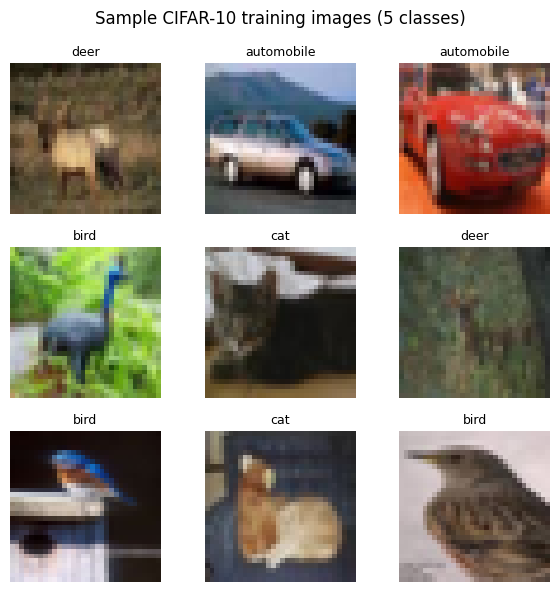

In [46]:
NUM_CIFAR_CLASSES = 5
IMG_R, IMG_C, CHANNELS = 32, 32, 3

(x_c_train, y_c_train), (x_c_test, y_c_test) = cifar10.load_data()

# Keep only the first 30 000 training samples
x_c_train = x_c_train[:30000]
y_c_train = y_c_train[:30000]

# Keep only classes 0-4
mask_tr = y_c_train.reshape(-1) < NUM_CIFAR_CLASSES
mask_te = y_c_test .reshape(-1) < NUM_CIFAR_CLASSES

x_c_train, y_c_train = x_c_train[mask_tr], y_c_train[mask_tr]
x_c_test,  y_c_test  = x_c_test [mask_te], y_c_test [mask_te]

# Save raw uint8 copies for visualisation
xx_test = x_c_test.copy()
yy_test = y_c_test.copy()

print(f"Train: {x_c_train.shape}  Test: {x_c_test.shape}")

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_c_train[i])
    ax.set_title(CLASS_NAMES[int(y_c_train[i])], fontsize=9)
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 training images (5 classes)")
plt.tight_layout()
plt.show()

## 3.5  Preprocess: reshape, normalise with mean/std

In [47]:
x_c_train = x_c_train.reshape(-1, IMG_R, IMG_C, CHANNELS).astype('float32')
x_c_test  = x_c_test .reshape(-1, IMG_R, IMG_C, CHANNELS).astype('float32')

# Standardise: zero mean, unit variance (better than /255 for colour images)
mean = np.mean(x_c_train)
std  = np.std(x_c_train)
x_c_train = (x_c_train - mean) / std
x_c_test  = (x_c_test  - mean) / std

print(f"After normalisation — mean: {x_c_train.mean():.3f}  std: {x_c_train.std():.3f}")

y_c_train = tf.keras.utils.to_categorical(y_c_train, NUM_CIFAR_CLASSES)
y_c_test  = tf.keras.utils.to_categorical(y_c_test,  NUM_CIFAR_CLASSES)

After normalisation — mean: 0.000  std: 1.000


> **Check ✏️:** We divide by `std` here instead of just `255`. Why might zero-mean, unit-variance normalisation be better for training?

## 3.6  Build a deeper CNN with BatchNormalization

**Batch Normalisation** normalises the activations within each mini-batch, which:
- speeds up training
- acts as mild regularisation
- reduces sensitivity to weight initialisation

In [48]:
def build_cifar_model(name='cifar_model'):
    """Builds the CNN for CIFAR-10 (5 classes)."""
    nf = 32        # base number of filters
    dr_c = 0.1     # dropout rate for conv blocks
    dr_d = 0.5     # dropout rate for dense layer

    m = Sequential(name=name)

    # Block 1
    m.add(Conv2D(nf,   (3,3), activation='relu', padding='same', input_shape=(IMG_R, IMG_C, CHANNELS)))
    m.add(BatchNormalization())
    m.add(Conv2D(nf,   (3,3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(2,2))
    m.add(Dropout(dr_c))

    # Block 2
    m.add(Conv2D(2*nf, (3,3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(Conv2D(2*nf, (3,3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(2,2))
    m.add(Dropout(dr_c))

    # Block 3
    m.add(Conv2D(4*nf, (3,3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(Conv2D(4*nf, (3,3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(2,2))
    m.add(Dropout(dr_c))

    # Classifier head
    m.add(Flatten())
    m.add(Dense(512, activation='relu'))
    m.add(BatchNormalization())
    m.add(Dropout(dr_d))
    m.add(Dense(NUM_CIFAR_CLASSES, activation='softmax'))

    m.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])
    return m

cifar_model = build_cifar_model('cifar_no_aug')
cifar_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cifar_no_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,342,501 (5.12 MB)

 Trainable params: 1,340,581 (5.11 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 3.7  Train **without** augmentation (baseline)

In [49]:
es_cifar = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_no_aug = cifar_model.fit(
    x_c_train, y_c_train,
    batch_size=128,
    epochs=100,
    validation_data=(x_c_test, y_c_test),
    callbacks=[es_cifar],
    verbose=1
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.5715 - loss: 1.2633 - val_accuracy: 0.2000 - val_loss: 2.5290
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6834 - loss: 0.8394 - val_accuracy: 0.4136 - val_loss: 1.6827
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7397 - loss: 0.6725 - val_accuracy: 0.5832 - val_loss: 1.0736
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7868 - loss: 0.5673 - val_accuracy: 0.7350 - val_loss: 0.6941
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8162 - loss: 0.4915 - val_accuracy: 0.7646 - val_loss: 0.6362
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8389 - loss: 0.4263 - val_accuracy: 0.7868 - val_loss: 0.6004
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8610 - loss: 0.3758 - val_accuracy: 0.7768 - val_loss: 0.6575
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8800 - loss: 0.3257 

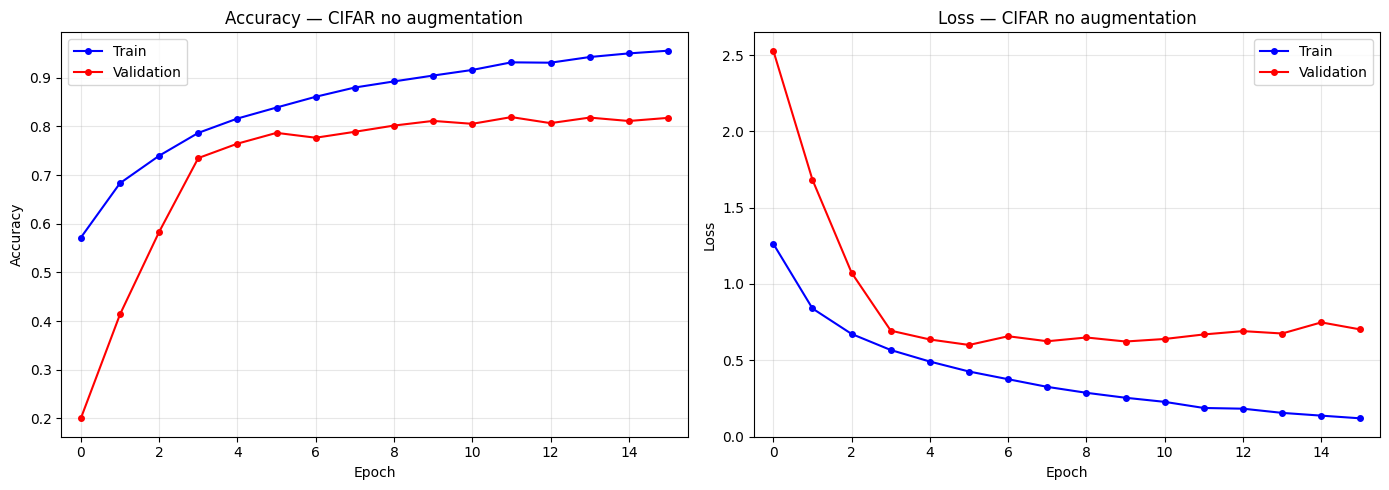

Test accuracy WITHOUT augmentation: 78.68%


In [50]:
plot_history(history_no_aug, '— CIFAR no augmentation')

acc_no_aug = cifar_model.evaluate(x_c_test, y_c_test, verbose=0)[1]
print(f"Test accuracy WITHOUT augmentation: {acc_no_aug*100:.2f}%")

> **Check ✏️ — Overfitting?**
> Compare train vs. validation curves. Is the gap larger or smaller than in the MNIST CNN?
> Why might CIFAR-10 overfit more easily than MNIST?

## 3.8  Confusion matrix — CIFAR-10 (5 classes)

In [51]:
y_pred_prob_noaug = cifar_model.predict(x_c_test, verbose=0)
y_pred_noaug  = np.argmax(y_pred_prob_noaug, axis=1)

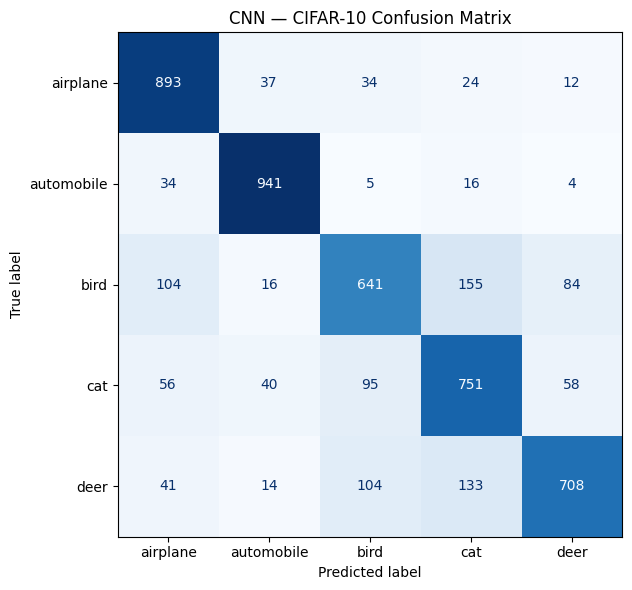

In [52]:
cm_cifar = confusion_matrix(np.argmax(y_c_test, axis=1), y_pred_noaug)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_cifar,
                               display_labels=CLASS_NAMES[:NUM_CIFAR_CLASSES])
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.set_title('CNN — CIFAR-10 Confusion Matrix')
plt.tight_layout()
plt.show()

## 3.9  Set up the augmentation pipeline

In [53]:
datagen = ImageDataGenerator(
    rotation_range=5,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.05
)
datagen.fit(x_c_train)

### Visualise a batch of augmented images

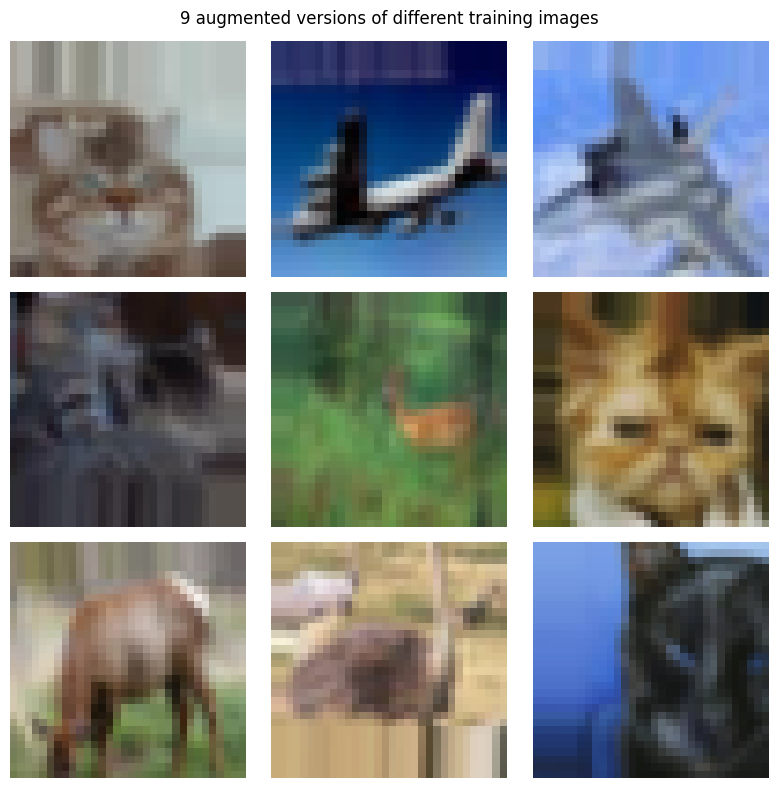

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for (X_batch, _), ax in zip(datagen.flow(x_c_train, y_c_train, batch_size=1), axes.flat):
    ax.imshow((X_batch[0] * std + mean).clip(0, 255).astype(np.uint8))
    ax.axis('off')
plt.suptitle("9 augmented versions of different training images")
plt.tight_layout()
plt.show()

### Visualise 25 augmentations of a **single** image

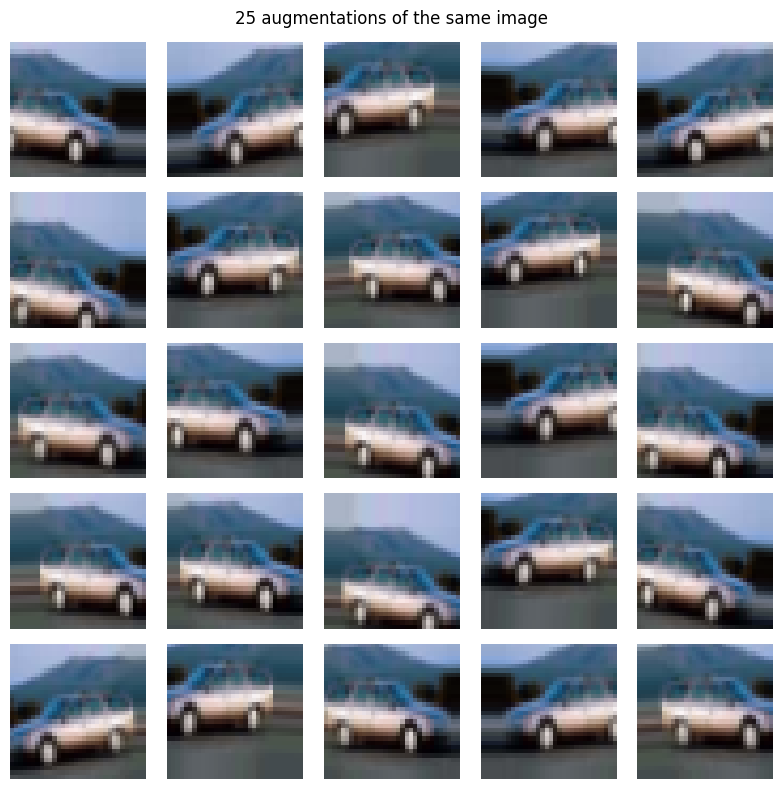

In [55]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, (ax, (X_batch, _)) in enumerate(
        zip(axes.flat, datagen.flow(x_c_train[1:2], y_c_train[1:2], batch_size=1, shuffle=False))):
    ax.imshow((X_batch[0] * std + mean).clip(0, 255).astype(np.uint8))
    ax.axis('off')
    if i >= 24:
        break
plt.suptitle("25 augmentations of the same image")
plt.tight_layout()
plt.show()

## 3.10  Build a bigger CNN
nf = 64 :        bigger number of filters

In [66]:
def build_cifar_model_big(name='cifar_model_big'):
    """Builds the CNN for CIFAR-10 (5 classes)."""
    nf = 64        # base number of filters
    dr_c = 0.1     # dropout rate for conv blocks
    dr_d = 0.5     # dropout rate for dense layer

    reg = l2(1e-4)

    m = Sequential(name=name)

    # Block 1
    m.add(Conv2D(nf,   (3,3), activation='relu', padding='same', input_shape=(IMG_R, IMG_C, CHANNELS), kernel_regularizer=reg))
    m.add(BatchNormalization())
    m.add(Conv2D(nf,   (3,3), activation='relu', padding='same', kernel_regularizer=reg))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(2,2))
    m.add(Dropout(dr_c))

    # Block 2
    m.add(Conv2D(2*nf, (3,3), activation='relu', padding='same', kernel_regularizer=reg))
    m.add(BatchNormalization())
    m.add(Conv2D(2*nf, (3,3), activation='relu', padding='same', kernel_regularizer=reg))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(2,2))
    m.add(Dropout(dr_c))

    # Block 3
    m.add(Conv2D(4*nf, (3,3), activation='relu', padding='same', kernel_regularizer=reg))
    m.add(BatchNormalization())
    m.add(Conv2D(4*nf, (3,3), activation='relu', padding='same', kernel_regularizer=reg))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(2,2))
    m.add(Dropout(dr_c))

    # Classifier head
    m.add(Flatten())
    m.add(Dense(512, activation='relu', kernel_regularizer=reg))
    m.add(BatchNormalization())
    m.add(Dropout(dr_d))
    m.add(Dense(NUM_CIFAR_CLASSES, activation='softmax', kernel_regularizer=reg))

    m.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])
    return m

cifar_model_aug = build_cifar_model_big('cifar_augmentation')
cifar_model_aug.summary()

Model: "cifar_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,251,269 (12.40 MB)

 Trainable params: 3,248,453 (12.39 MB)

 Non-trainable params: 2,816 (11.00 KB)

## 3.11  Train **with** augmentation

In [67]:

es_aug = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_aug = cifar_model_aug.fit(
    datagen.flow(x_c_train, y_c_train, batch_size=128),
    steps_per_epoch=len(x_c_train) // 128,
    epochs=100,
    validation_data=(x_c_test, y_c_test),
    callbacks=[es_aug],
    verbose=1
)

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 35s 180ms/step - accuracy: 0.5096 - loss: 1.5774 - val_accuracy: 0.3054 - val_loss: 2.6619
Epoch 2/100
  1/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4844 - loss: 1.5009

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4844 - loss: 1.5009 - val_accuracy: 0.2744 - val_loss: 2.7379
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.6109 - loss: 1.2141 - val_accuracy: 0.3150 - val_loss: 2.5280
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6797 - loss: 1.0629 - val_accuracy: 0.3160 - val_loss: 2.5166
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.6645 - loss: 1.0608 - val_accuracy: 0.6398 - val_loss: 1.0648
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6406 - loss: 1.1118 - val_accuracy: 0.6184 - val_loss: 1.1203
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.7011 - loss: 0.9657 - val_accuracy: 0.7364 - val_loss: 0.8436
Epoch 8/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6875 - loss: 1.0424 - val_accuracy: 0.7452 - val_loss: 0.8278
Epoch 9/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.7284 - loss: 0.8959 - val_accuracy

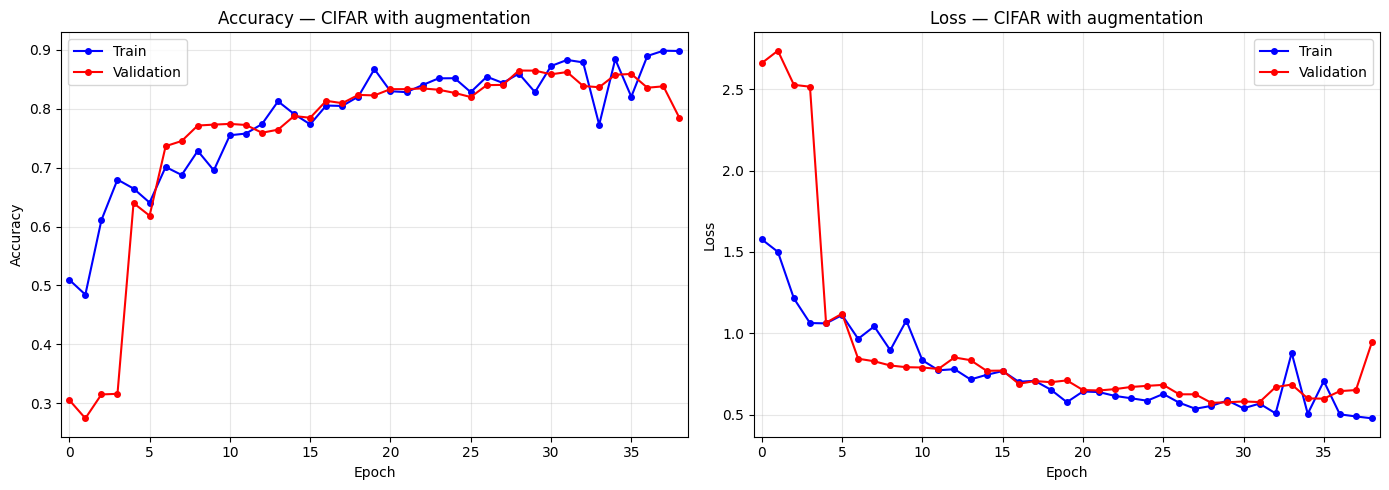

Test accuracy WITH    augmentation: 86.48%
Test accuracy WITHOUT augmentation: 78.68%
Improvement: +7.80 percentage points


In [68]:
plot_history(history_aug, '— CIFAR with augmentation')

acc_aug = cifar_model_aug.evaluate(x_c_test, y_c_test, verbose=0)[1]
print(f"Test accuracy WITH    augmentation: {acc_aug*100:.2f}%")
print(f"Test accuracy WITHOUT augmentation: {acc_no_aug*100:.2f}%")
print(f"Improvement: {(acc_aug - acc_no_aug)*100:+.2f} percentage points")

## 3.12  Visualise predictions with probability bars

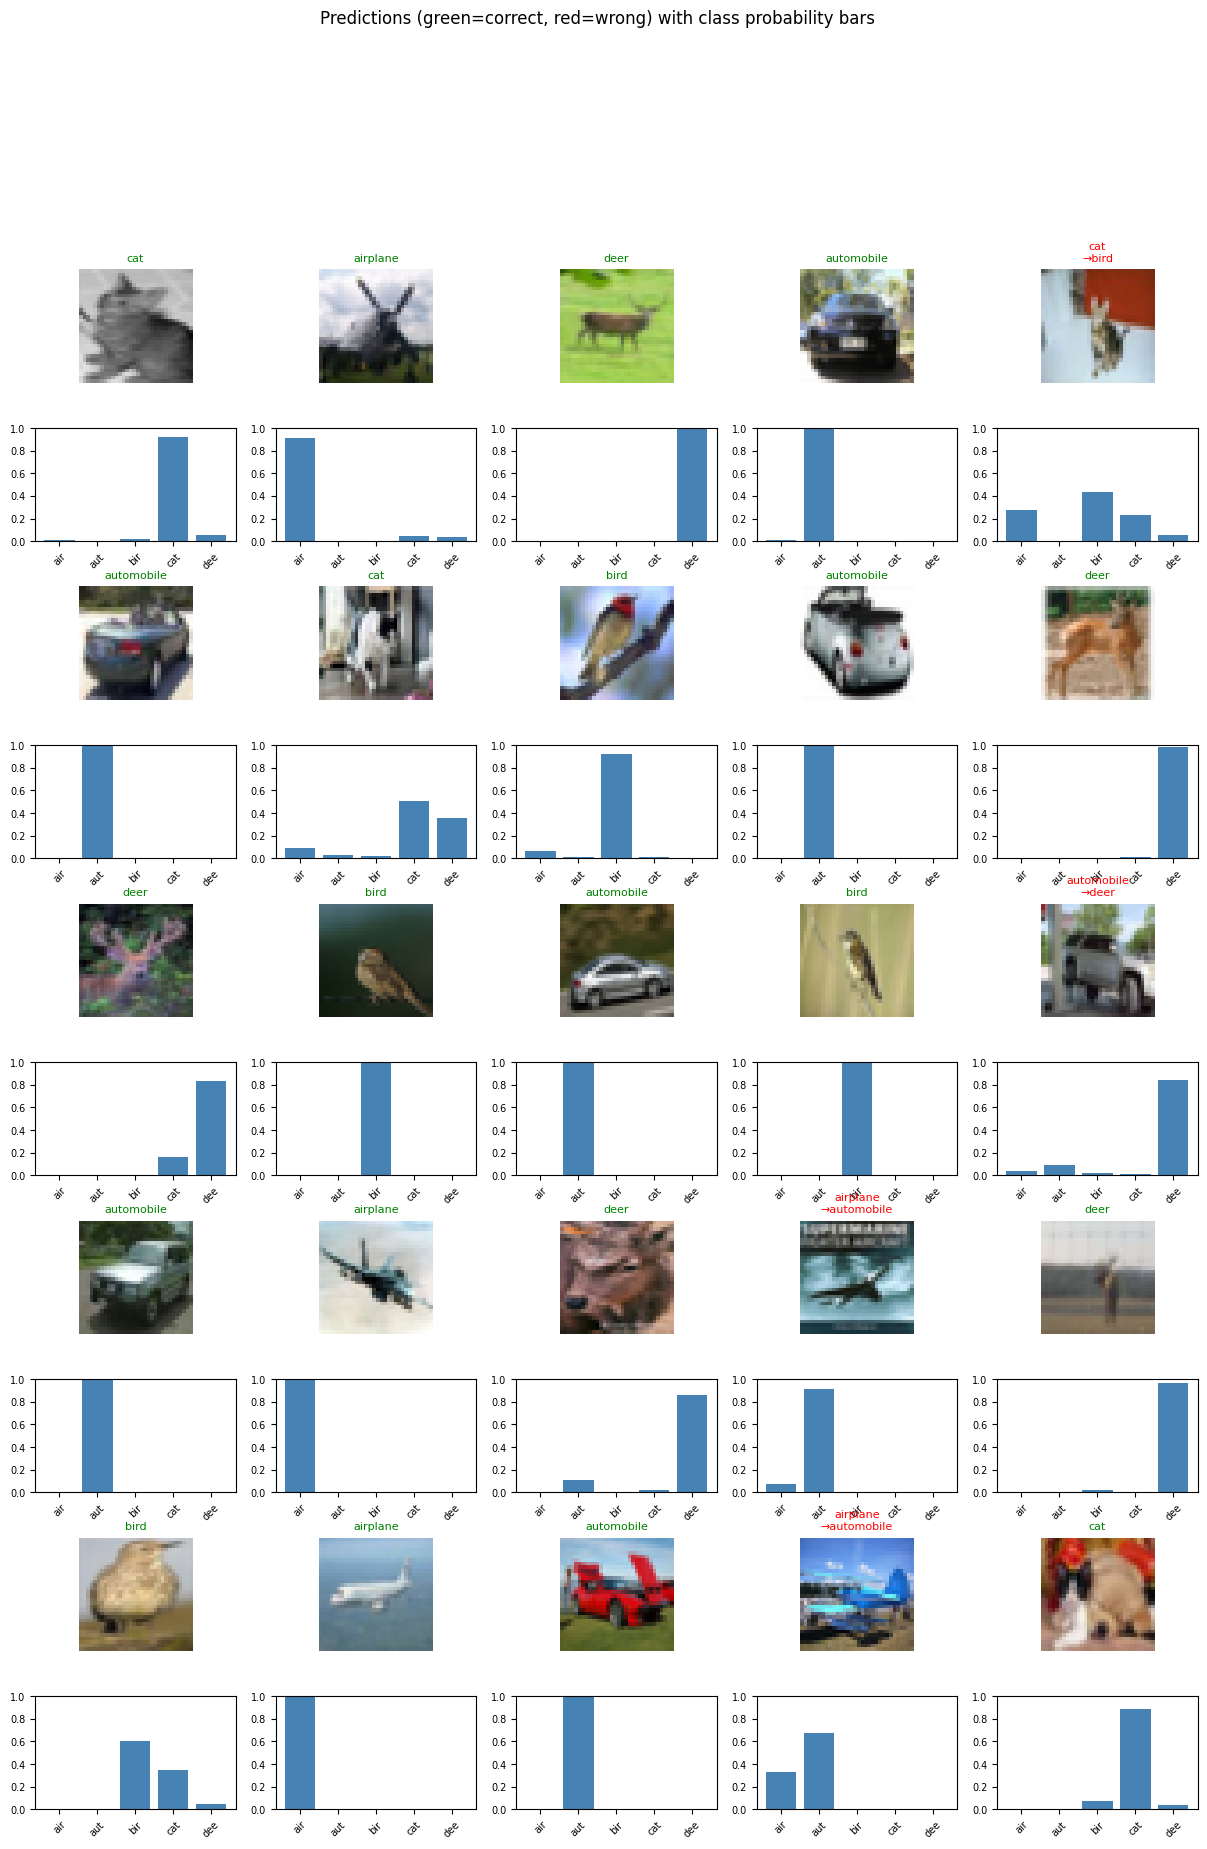

In [69]:
y_pred_prob = cifar_model_aug.predict(x_c_test, verbose=0)
y_pred_aug  = np.argmax(y_pred_prob, axis=1)

GRID = 5
fig, axes = plt.subplots(GRID*2, GRID, figsize=(GRID*3, GRID*4))
fig.subplots_adjust(hspace=0.4)

for col in range(GRID):
    for row in range(GRID):
        i_img = random.randrange(len(xx_test))
        img_ax  = axes[row*2,     col]
        bar_ax  = axes[row*2 + 1, col]

        img_ax.imshow(xx_test[i_img])
        img_ax.axis('off')
        true_c = int(np.squeeze(yy_test[i_img]))
        pred_c = y_pred_aug[i_img]
        color  = 'green' if true_c == pred_c else 'red'
        label  = CLASS_NAMES[true_c] if true_c == pred_c else f"{CLASS_NAMES[true_c]}\n→{CLASS_NAMES[pred_c]}"
        img_ax.set_title(label, color=color, fontsize=8)

        bar_ax.bar(range(NUM_CIFAR_CLASSES), y_pred_prob[i_img], color='steelblue')
        bar_ax.set_xticks(range(NUM_CIFAR_CLASSES))
        bar_ax.set_xticklabels([n[:3] for n in CLASS_NAMES[:NUM_CIFAR_CLASSES]], fontsize=7, rotation=45)
        bar_ax.set_ylim(0, 1)
        bar_ax.tick_params(axis='y', labelsize=7)

plt.suptitle("Predictions (green=correct, red=wrong) with class probability bars", y=1.01)
plt.show()

## 3.12  Confusion matrix — CIFAR-10 (5 classes)

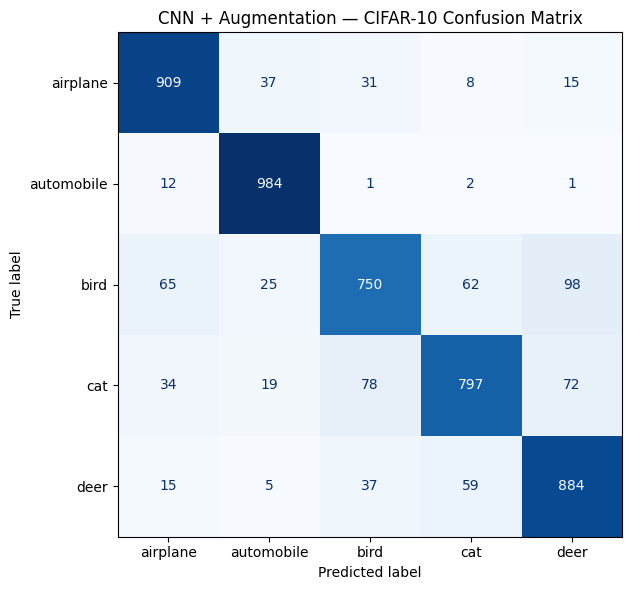

In [70]:
cm_cifar = confusion_matrix(np.argmax(y_c_test, axis=1), y_pred_aug)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_cifar,
                               display_labels=CLASS_NAMES[:NUM_CIFAR_CLASSES])
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.set_title('CNN + Augmentation — CIFAR-10 Confusion Matrix')
plt.tight_layout()
plt.show()

## ✏️ Exercises — Data Augmentation

### Exercise 1: Tweak augmentation parameters
Try `rotation_range=5` and `zoom_range=0.05`. Retrain.  
- Does less aggressive augmentation help or hurt? **Answer**: Small help


### Exercise 2: Add L2 regularisation
Uncomment `reg = l2(1e-4)` and pass it to each Conv2D and Dense layer as `kernel_regularizer=reg`.  
- Does combining L2 + Dropout + Augmentation further reduce overfitting? **Answer**: Yes

<center>

---
---

# 🟢 Summary

---
---
</center>

## Final results table

In [ ]:
s_dnn    = dnn_model    .evaluate(x_test,          y_test,          verbose=0)
s_cnn    = cnn_model    .evaluate(x_test_cnn,      y_test_cnn,      verbose=0)
s_no_aug = cifar_model  .evaluate(x_c_test,        y_c_test,        verbose=0)
s_aug    = cifar_model_aug.evaluate(x_c_test,      y_c_test,        verbose=0)

rows = [
    ("DNN (MNIST)",                  "fully-connected, 3×256",   "Adam",   s_dnn[1]*100),
    ("CNN (MNIST)",                  "4×Conv2D + 2×MaxPool",     "Adam",   s_cnn[1]*100),
    ("CNN CIFAR-10 (no aug)",        "6×Conv2D + BatchNorm",     "Adam",   s_no_aug[1]*100),
    ("CNN CIFAR-10 (+ augmentation)","same + ImageDataGenerator","Adam",   s_aug[1]*100),
]

print(f"{'Model':<35} {'Architecture':<30} {'Optimizer':<10} {'Test Acc':>10}")
print("─"*90)
for name, arch, opt, acc in rows:
    print(f"{name:<35} {arch:<30} {opt:<10} {acc:>9.2f}%")

Model                               Architecture                   Optimizer    Test Acc
──────────────────────────────────────────────────────────────────────────────────────────
DNN (MNIST)                         fully-connected, 3×256         Adam           98.23%
CNN (MNIST)                         4×Conv2D + 2×MaxPool           Adam           99.47%
CNN CIFAR-10 (no aug)               6×Conv2D + BatchNorm           Adam           78.90%
CNN CIFAR-10 (+ augmentation)       same + ImageDataGenerator      Adam           86.48%


## Key takeaways

1. **Deep NNs** learn features automatically — no hand-crafting required
2. **CNNs** exploit spatial structure via weight sharing → better accuracy with fewer parameters on image data
3. **Dropout & BatchNorm** are essential regularisation tools to prevent overfitting
4. **Data augmentation** artificially expands the training set and is one of the most effective ways to improve generalisation
5. **EarlyStopping** prevents wasted computation and automatically selects the best model checkpoint

## Further reading

- 📖 Chollet, *Deep Learning with Python* (Manning, 2021)
- 🌐 MIT Introduction to Deep Learning: http://introtodeeplearning.com/
